In [1]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 25

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 24.36 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149031 entries, 0 to 149030
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 490.1+ MB
None


In [ ]:
df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)

In [ ]:
filtered = (df['season'] == 20252026) & (df['event'] == 26) & (df['player_name_id'] == 'Bukayo Saka')
df_gw26 = df[filtered]
df_gw26[['player_name_id','event','fixture','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

In [4]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

#add this info to a settings dict?
stats_current_gameweek = current_gw
picks_current_gameweek = current_gw
# current_season = 20252026

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 40030

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35508    88.70            4522
                        recoveries_elo_p90sq_3      35508    88.70            4522
                               tackles_p90sq_3      35508    88.70            4522
                           tackles_elo_p90sq_3      35508    88.70            4522
                                   cbi_p90sq_3      35508    88.70            4522
                               cbi_elo_p90sq_3      35508    88.70            4522
                        defensive_cont_p90sq_3      35508    88.70            4522
                    defensive_cont_elo_p90sq_3      35508    88.70            4522
                               tackles_p90sq_5      35474    88.62            4556
                           tackles_elo_p90sq_5      35474    88

In [5]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>20)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132351,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132354,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132357,Bukayo Saka,23.0,2.0,Man Utd,0.359322
132360,Bukayo Saka,24.0,0.0,Leeds,0.356240
132363,Bukayo Saka,25.0,0.0,Sunderland,0.356240
132317,Bukayo Saka,26.0,NaN,Brentford,0.356240
132366,Bukayo Saka,27.0,NaN,Spurs,0.356240
132367,Bukayo Saka,28.0,NaN,Chelsea,0.356240
132368,Bukayo Saka,29.0,NaN,Brighton,0.356240
132369,Bukayo Saka,30.0,NaN,Everton,0.356240


In [6]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [7]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [8]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [9]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [10]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2347/7407

Training Set Performance:
R² Score: 0.8413
RMSE: 13.0760
MAE: 10.8256

Test Set Performance:
R² Score: 0.3667
RMSE: 26.2627
MAE: 21.4131

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.257782
          minutes_elo_3    0.059298
   opp_team_elo_p90sq_3    0.037412
  opp_team_elo_p90sq_10    0.014978
  opp_team_elo_p90sq_at    0.013060
      team_elo_p90sq_10    0.013050
       team_elo_p90sq_5    0.010104
opp_team_elo_elo_p90_10    0.008814
      team_elo_p90sq_at    0.008642
  clean_sheets_p90sq_at    0.008439
         opp_team_elo_3    0.008396
           bps_p90sq_at    0.007921
               elo_diff    0.007662
   opp_team_elo_p90sq_5    0.007647
           opp_team_elo    0.007574
         opp_team_elo_5    0.007441
       team_elo_p90sq_3    0.007216
        goals_scored_10    0.007014
        opp_team_elo_10    0.006897
goals_conceded_p90sq_at    0.006370


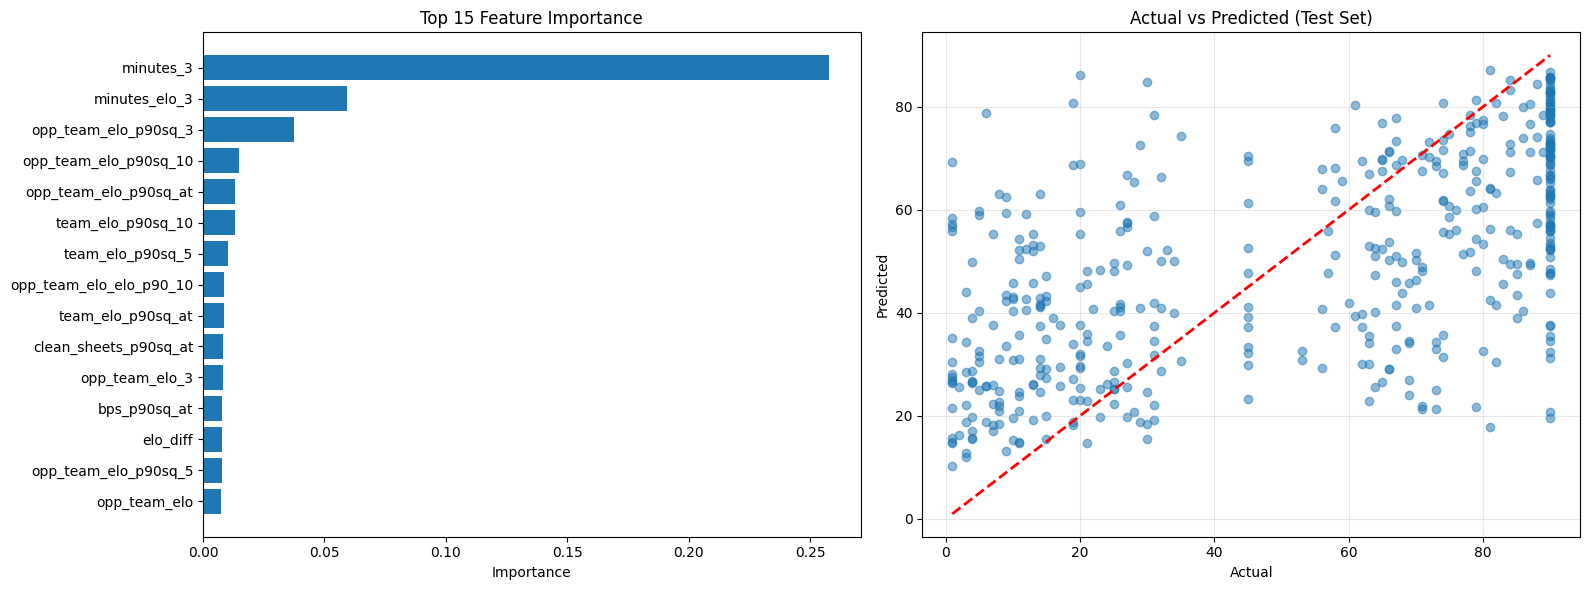

Cleaned df size: 8154/27695

Training Set Performance:
R² Score: 0.6709
RMSE: 18.4788
MAE: 15.2454

Test Set Performance:
R² Score: 0.3242
RMSE: 26.3955
MAE: 21.5997

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.358924
  opp_team_elo_p90sq_10    0.021959
   opp_team_elo_p90sq_3    0.019384
   opp_team_elo_p90sq_5    0.015580
                 bps_10    0.012614
             minutes_10    0.010454
          minutes_elo_3    0.009677
        xg_over_g_ratio    0.008854
         minutes_elo_10    0.008723
      minutes_elo_p90_5    0.008636
           opp_team_elo    0.007779
  goals_conceded_elo_10    0.007403
  clean_sheets_p90sq_at    0.006968
      team_elo_p90sq_10    0.006953
goals_conceded_p90sq_at    0.006740
  opp_team_elo_p90sq_at    0.006687
             bps_elo_10    0.006617
         opp_team_elo_3    0.006171
                  bps_3    0.006049
         bonus_p90sq_at    0.006005


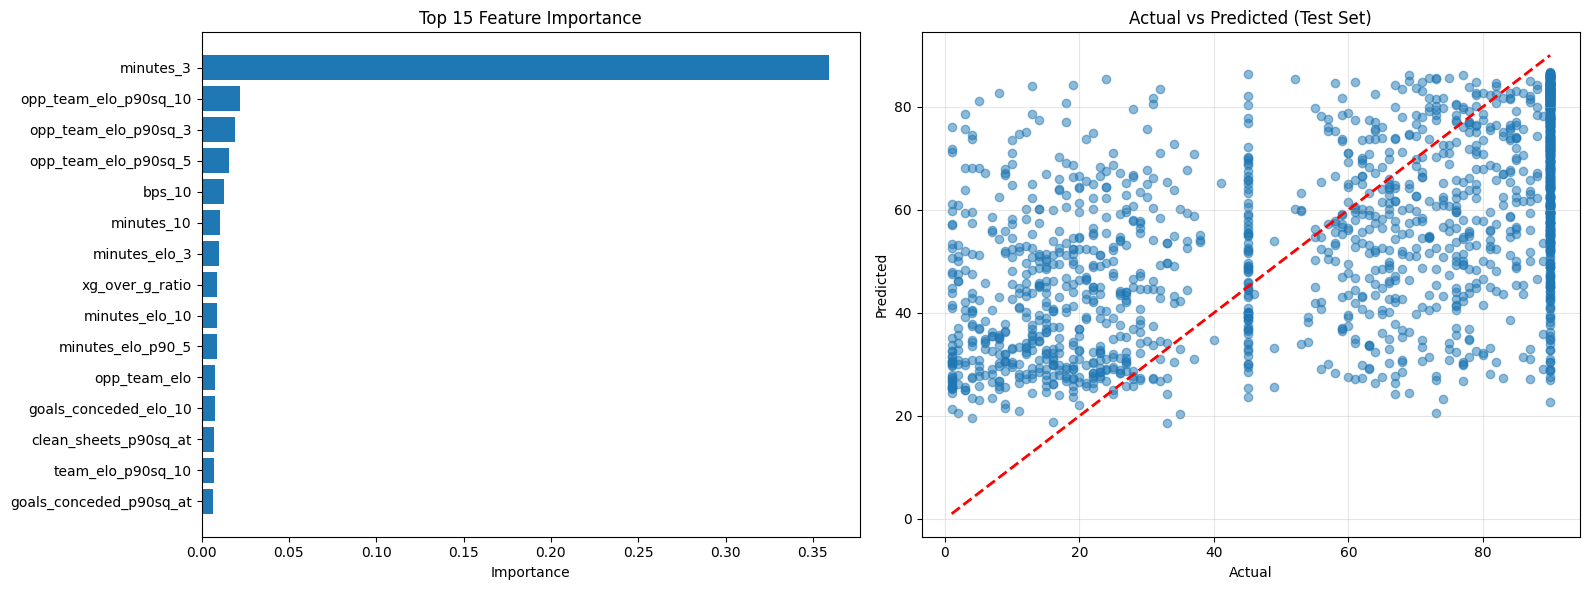

Cleaned df size: 5087/19941

Training Set Performance:
R² Score: 0.6852
RMSE: 16.5867
MAE: 12.4999

Test Set Performance:
R² Score: 0.2391
RMSE: 25.0865
MAE: 18.5174

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.091875
        team_elo_p90sq_3    0.079345
    opp_team_elo_p90sq_3    0.072626
   opp_team_elo_p90sq_10    0.018255
           minutes_elo_3    0.015893
         xg_over_g_ratio    0.014214
    opp_team_elo_p90sq_5    0.014152
         opp_team_elo_10    0.012537
       xassists_p90sq_at    0.012079
            opp_team_elo    0.010367
opp_team_elo_elo_p90sq_3    0.010366
          opp_team_elo_3    0.010113
 goals_conceded_p90sq_at    0.010108
       team_elo_p90sq_10    0.009523
        team_elo_p90sq_5    0.009178
               bps_elo_3    0.009139
                elo_diff    0.008937
                   bps_3    0.007611
            bps_p90sq_at    0.007454
   total_points_p90sq_at    0.007411


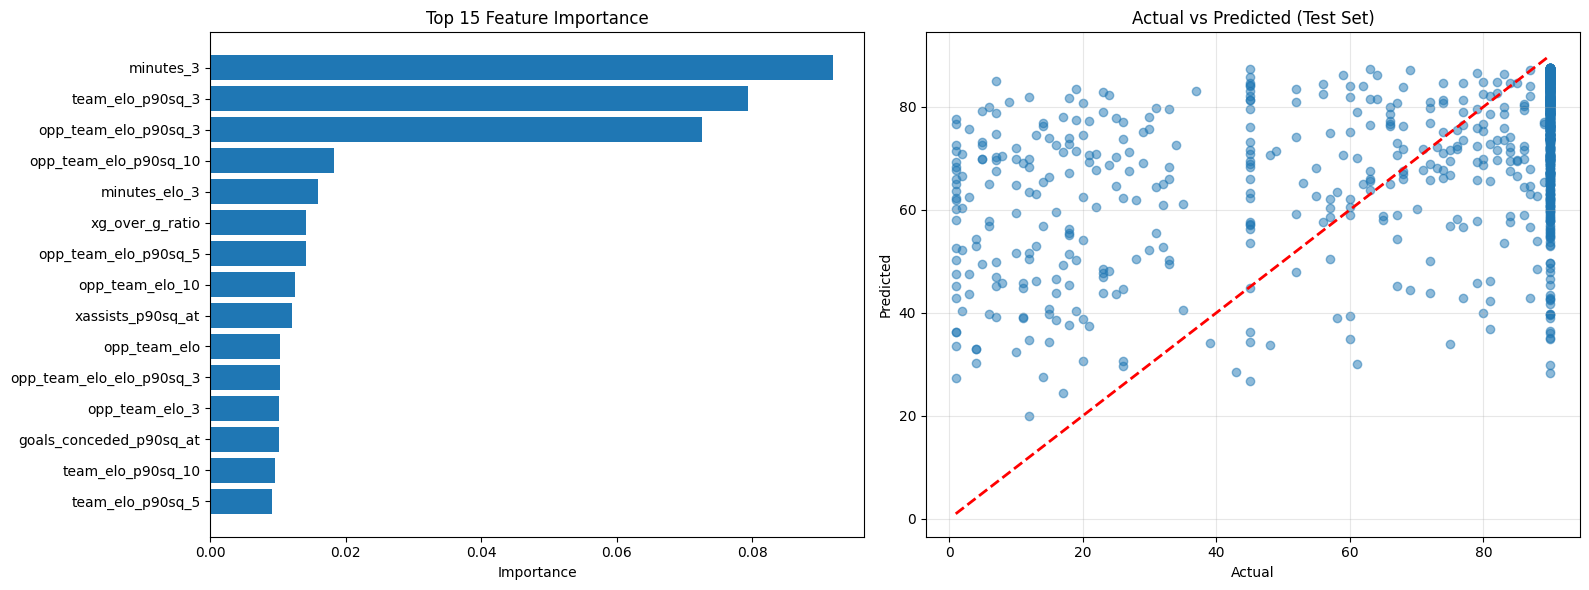

Cleaned df size: 3859/4121

Training Set Performance:
R² Score: 0.7489
RMSE: 2.5644
MAE: 0.5379

Test Set Performance:
R² Score: -0.0501
RMSE: 5.4709
MAE: 1.1957

Top 20 Feature Importances:
                 feature  importance
          team_elo_elo_3    0.053774
   opp_team_elo_p90sq_at    0.042867
             bps_p90sq_3    0.029901
          opp_team_elo_5    0.029858
            bps_p90sq_at    0.024094
       saves_elo_p90sq_3    0.022248
   total_points_p90sq_at    0.020806
          saves_p90sq_10    0.019690
                  bps_10    0.019484
       saves_elo_p90sq_5    0.019432
           saves_p90sq_3    0.018961
            opp_team_elo    0.018487
          opp_team_elo_3    0.017119
         opp_team_elo_10    0.016159
           minutes_elo_3    0.015470
total_points_elo_p90sq_5    0.015308
             bps_p90sq_5    0.014814
      saves_elo_p90sq_10    0.014688
   opp_team_elo_p90sq_10    0.013546
       team_elo_p90sq_at    0.013446


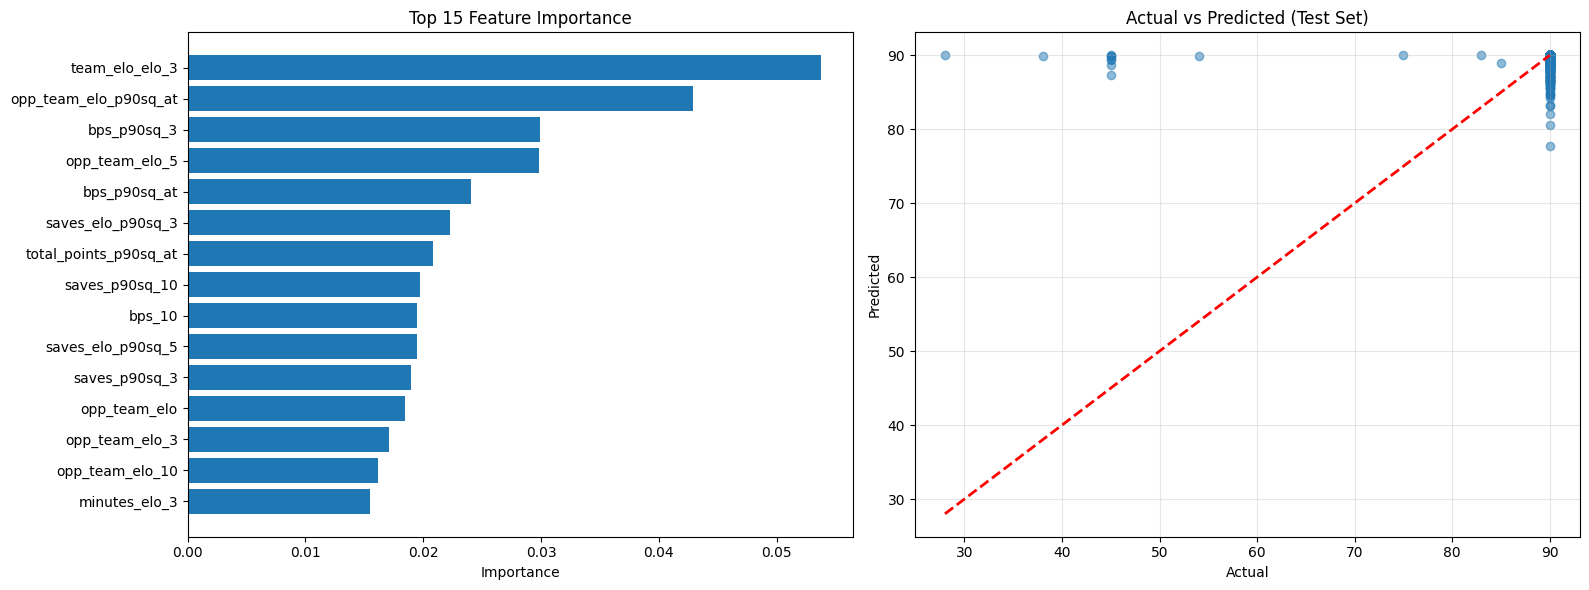

In [11]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2536/4259

Training Set Performance:
R² Score: 0.6080
RMSE: 0.2425
MAE: 0.1940

Test Set Performance:
R² Score: 0.0491
RMSE: 0.3900
MAE: 0.2998

Top 20 Feature Importances:
                  feature  importance
    goals_scored_p90sq_at    0.038898
                 elo_diff    0.030383
          xg_over_g_ratio    0.028589
             opp_team_elo    0.018542
           opp_team_elo_5    0.018465
           opp_team_elo_3    0.016954
          opp_team_elo_10    0.015516
         team_elo_p90sq_3    0.015439
     opp_team_elo_p90sq_5    0.014004
                 team_elo    0.012450
     opp_team_elo_p90sq_3    0.011795
total_points_elo_p90sq_10    0.011787
  goals_conceded_p90sq_at    0.011763
         team_elo_p90sq_5    0.011120
    clean_sheets_p90sq_at    0.011037
      total_points_p90_10    0.011015
    total_points_p90sq_at    0.010899
             bps_p90sq_at    0.010881
           bonus_p90sq_at    0.010634
    

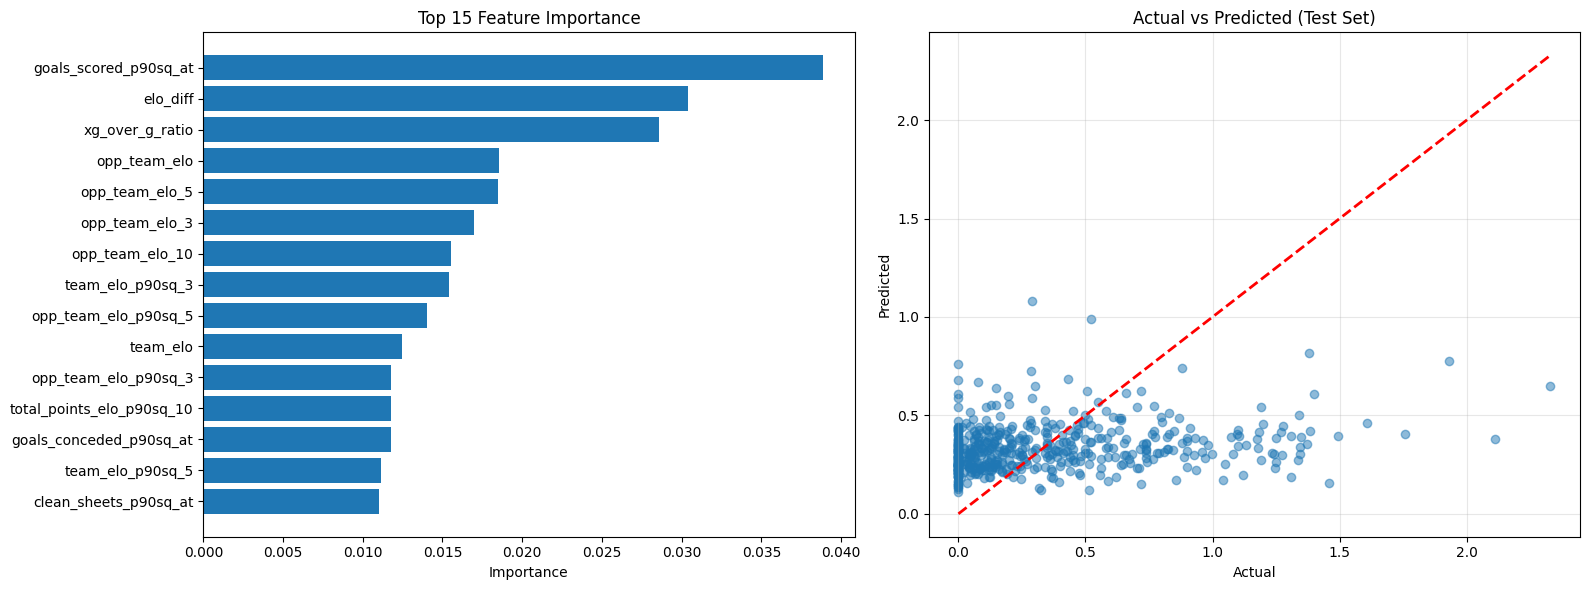

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 11790/18205

Training Set Performance:
R² Score: 0.3894
RMSE: 0.1764
MAE: 0.1190

Test Set Performance:
R² Score: 0.0730
RMSE: 0.1985
MAE: 0.1328

Top 20 Feature Importances:
                 feature  importance
   goals_scored_p90sq_at    0.155769
            opp_team_elo    0.036065
          bonus_p90sq_at    0.021793
         opp_team_elo_10    0.019416
                elo_diff    0.016921
          opp_team_elo_3    0.015306
            bps_p90sq_at    0.015206
     goals_scored_elo_10    0.013920
   clean_sheets_p90sq_at    0.013034
     total_points_elo_10    0.012963
          opp_team_elo_5    0.012884
       team_elo_p90sq_at    0.011766
            bps_p90sq_10    0.011657
 goals_conceded_p90sq_at    0.010666
total_points_elo_p90sq_3    0.010429
      total_points_p90_3    0.010092
    total_points_p90sq_3    0.009659
   opp_team_elo_p90sq_at    0.009456
              bps_elo_10    0.009064
   total_points_p90sq_

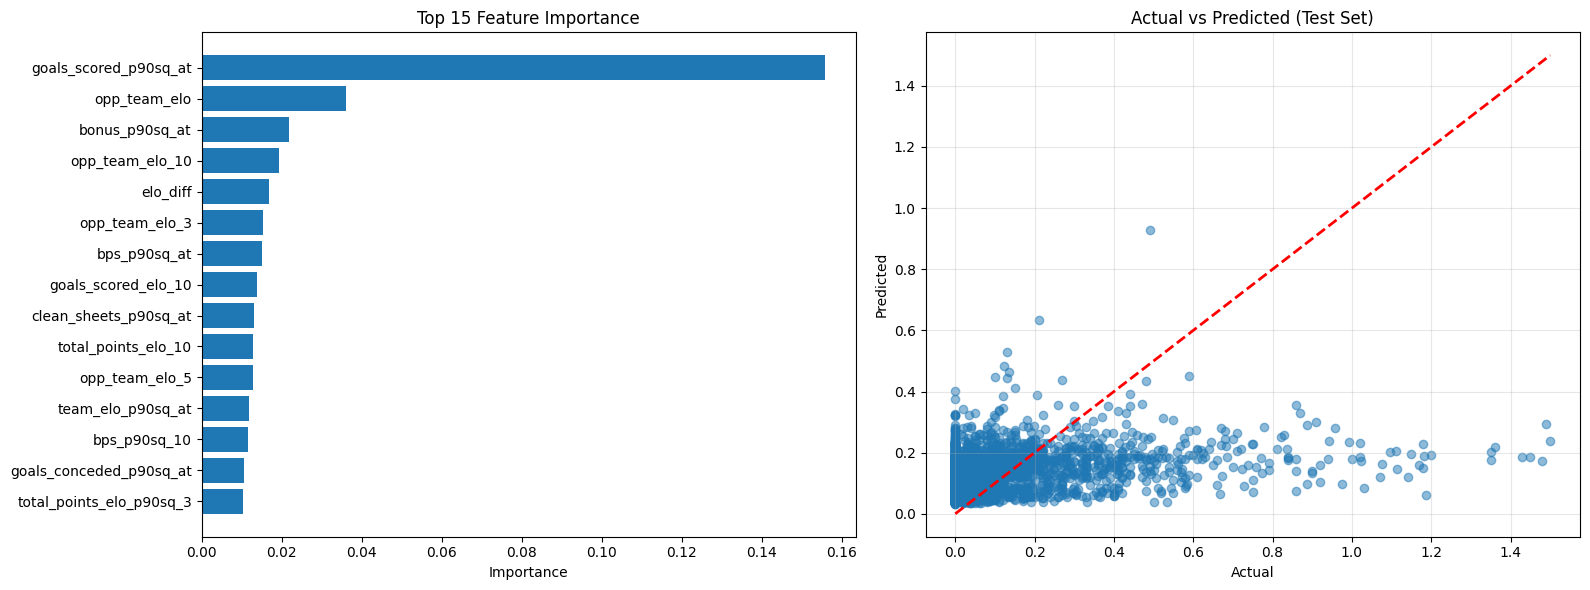

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 10100/16293

Training Set Performance:
R² Score: 0.2729
RMSE: 0.0910
MAE: 0.0550

Test Set Performance:
R² Score: -0.0353
RMSE: 0.1056
MAE: 0.0604

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.040460
             opp_team_elo_3    0.038061
               opp_team_elo    0.037518
      goals_conceded_elo_10    0.022497
               bps_p90sq_at    0.022148
     opp_team_elo_elo_p90_5    0.020083
      opp_team_elo_p90sq_10    0.019785
    goals_conceded_p90sq_at    0.019431
  goals_conceded_elo_p90_10    0.019201
                   elo_diff    0.018457
        goals_scored_elo_10    0.017737
          team_elo_p90sq_at    0.016561
      total_points_p90sq_at    0.015593
  total_points_elo_p90sq_10    0.015305
goals_conceded_elo_p90sq_10    0.015302
            opp_team_elo_10    0.013390
      opp_team_elo_p90sq_at    0.013284
             opp_team_elo_5    0.013193
 

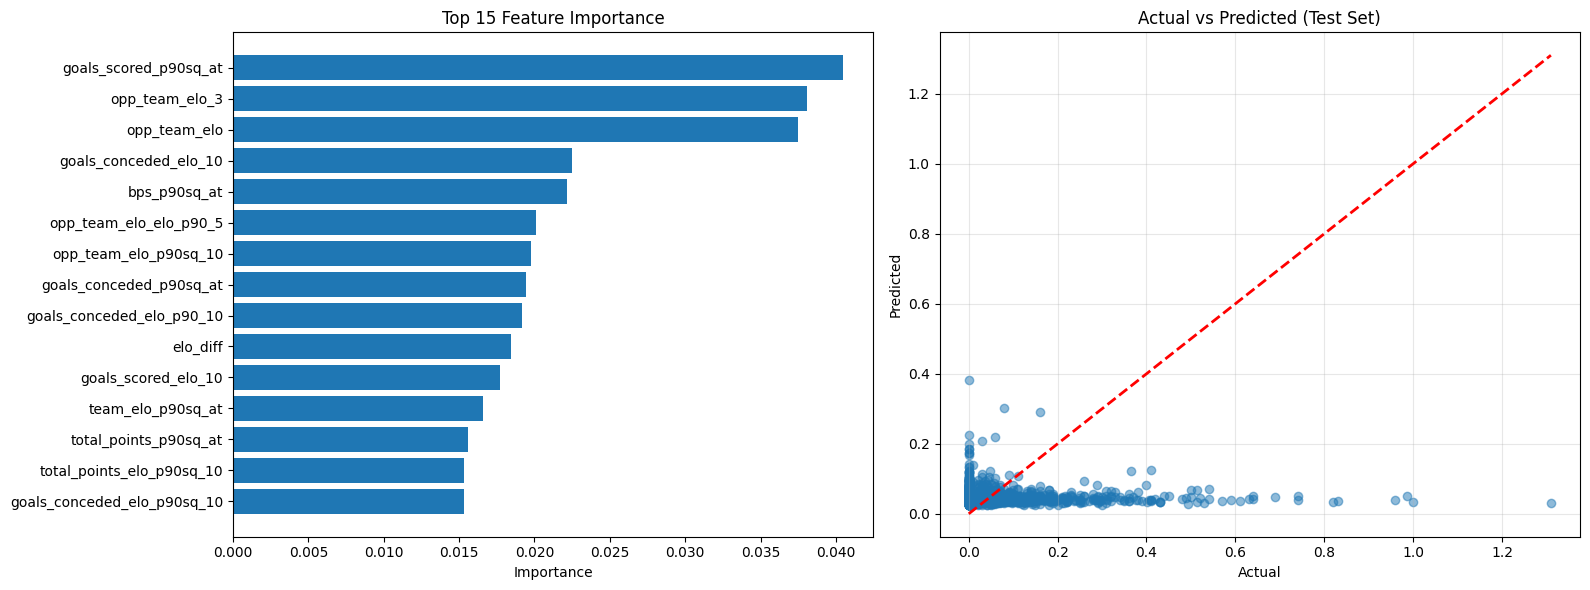

In [12]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2727/4538

Training Set Performance:
R² Score: 0.5196
RMSE: 0.0857
MAE: 0.0582

Test Set Performance:
R² Score: 0.0102
RMSE: 0.1018
MAE: 0.0665

Top 20 Feature Importances:
                feature  importance
           opp_team_elo    0.040255
      minutes_elo_p90_5    0.024232
         opp_team_elo_3    0.023467
               elo_diff    0.021383
           bonus_elo_10    0.018540
opp_team_elo_elo_p90_10    0.018214
         opp_team_elo_5    0.017944
   total_points_p90sq_3    0.015161
  goals_scored_p90sq_at    0.015047
        xg_over_g_ratio    0.014986
            bps_p90sq_3    0.014114
          bps_elo_p90_5    0.014086
          minutes_elo_3    0.013271
      minutes_elo_p90_3    0.012920
      team_elo_p90sq_at    0.012714
     minutes_elo_p90_10    0.012666
 total_points_elo_p90_3    0.012626
        bps_elo_p90sq_3    0.012449
   goals_conceded_elo_3    0.012369
             bps_elo_10    0.012112


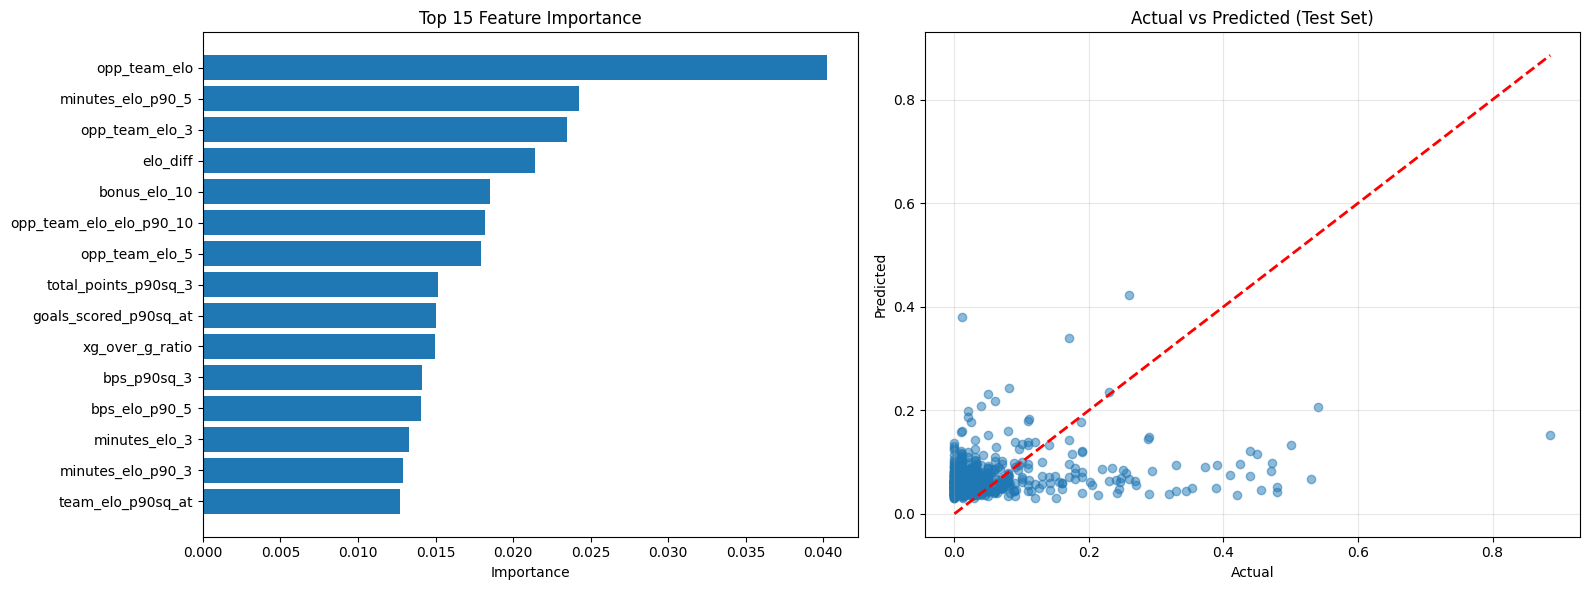

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 12211/18829

Training Set Performance:
R² Score: 0.4174
RMSE: 0.1239
MAE: 0.0877

Test Set Performance:
R² Score: 0.0623
RMSE: 0.1602
MAE: 0.1080

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.098818
         bonus_p90sq_at    0.072160
             bps_elo_10    0.031409
           opp_team_elo    0.023695
    total_points_elo_10    0.021620
  goals_scored_p90sq_at    0.020396
         opp_team_elo_5    0.017108
      team_elo_p90sq_at    0.015002
         opp_team_elo_3    0.012478
  clean_sheets_p90sq_at    0.011882
  total_points_p90sq_at    0.011726
        opp_team_elo_10    0.011472
goals_conceded_p90sq_at    0.011254
           bps_p90sq_at    0.010600
  opp_team_elo_p90sq_at    0.010555
           bps_p90sq_10    0.010341
                 bps_10    0.009590
             bps_p90_10    0.009260
        bps_elo_p90sq_5    0.008888
    total_points_p90_10    0.008529


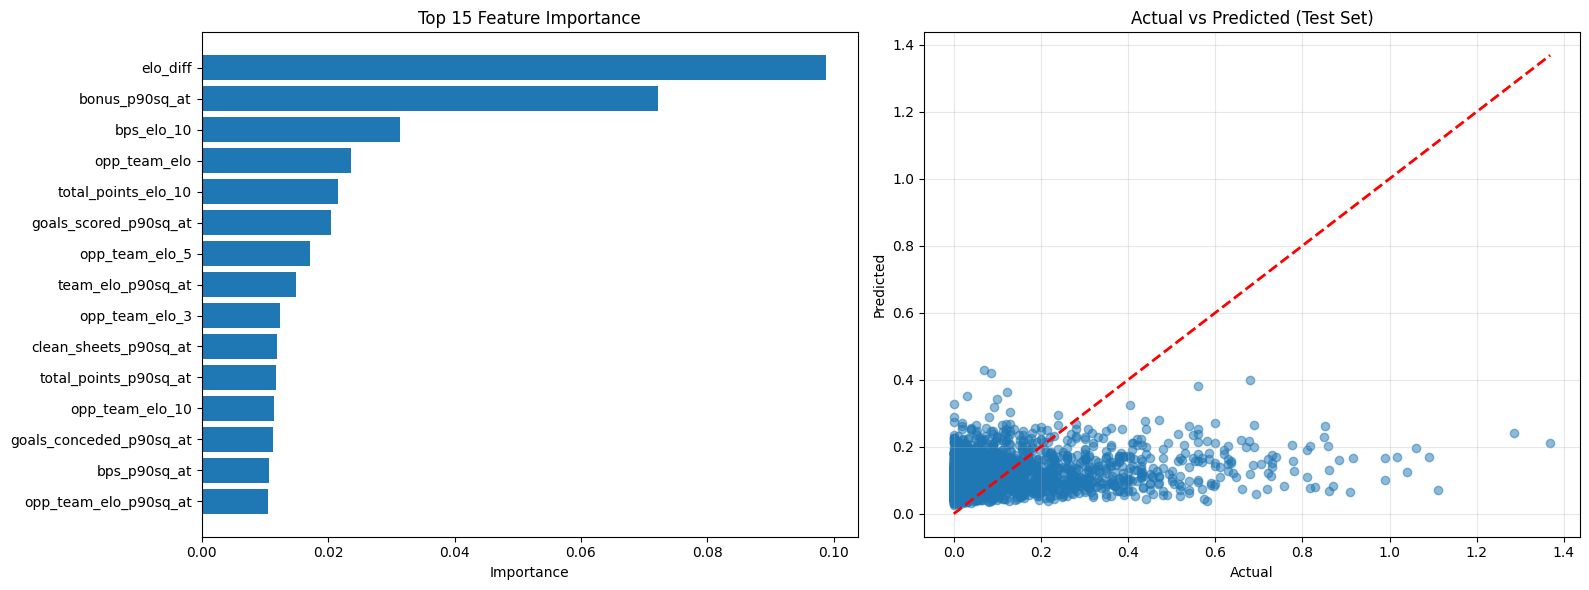

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10292/16608

Training Set Performance:
R² Score: 0.4001
RMSE: 0.0809
MAE: 0.0497

Test Set Performance:
R² Score: 0.0681
RMSE: 0.0985
MAE: 0.0573

Top 20 Feature Importances:
                feature  importance
         bonus_p90sq_at    0.090016
               elo_diff    0.042281
           opp_team_elo    0.028248
goals_conceded_p90sq_at    0.024950
  goals_scored_p90sq_at    0.017529
              bps_p90_5    0.016948
           bps_p90sq_at    0.016229
         opp_team_elo_3    0.014961
  opp_team_elo_p90sq_at    0.014147
            bps_p90sq_5    0.014133
               team_elo    0.014061
    total_points_p90_10    0.013600
   goals_conceded_elo_3    0.013403
  total_points_p90sq_10    0.013135
        opp_team_elo_10    0.013092
  total_points_p90sq_at    0.012267
         minutes_elo_10    0.012146
            bps_p90sq_3    0.011412
  clean_sheets_p90sq_at    0.011355
      team_elo_p90sq_at    0.011174


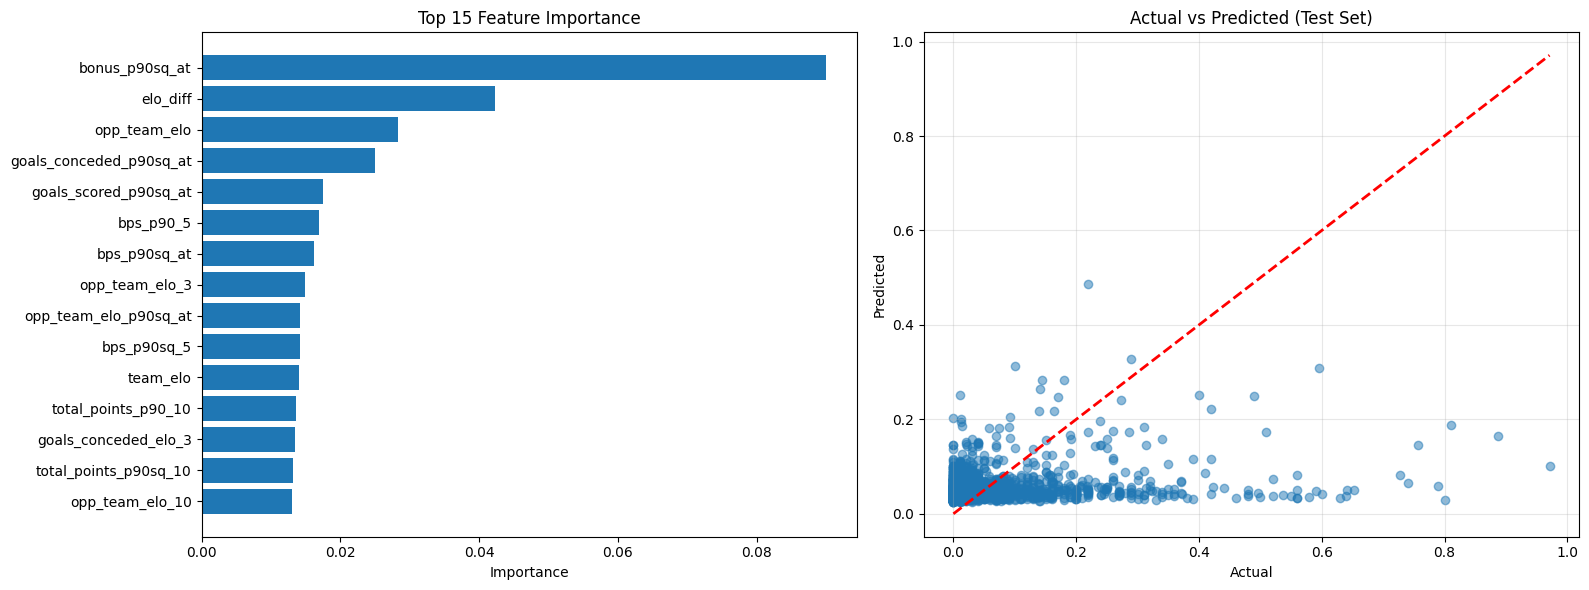

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2727/4538

Training Set Performance:
R² Score: 0.6618
RMSE: 0.5421
MAE: 0.4386

Test Set Performance:
R² Score: 0.1472
RMSE: 0.8613
MAE: 0.6718

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.144916
               opp_team_elo    0.063922
            xg_over_g_ratio    0.036499
      clean_sheets_p90sq_at    0.024511
            opp_team_elo_10    0.017025
    goals_conceded_p90sq_at    0.015776
             opp_team_elo_5    0.015620
             opp_team_elo_3    0.013598
       goals_conceded_elo_5    0.009756
             bonus_p90sq_at    0.009635
         minutes_elo_p90_10    0.009604
   total_points_elo_p90sq_3    0.008840
             team_elo_elo_5    0.008792
          team_elo_p90sq_at    0.008145
      goals_scored_p90sq_at    0.008141
    goals_conceded_p90sq_10    0.008106
               bps_p90sq_at    0.008074
          minutes_elo_p90_3    0.0

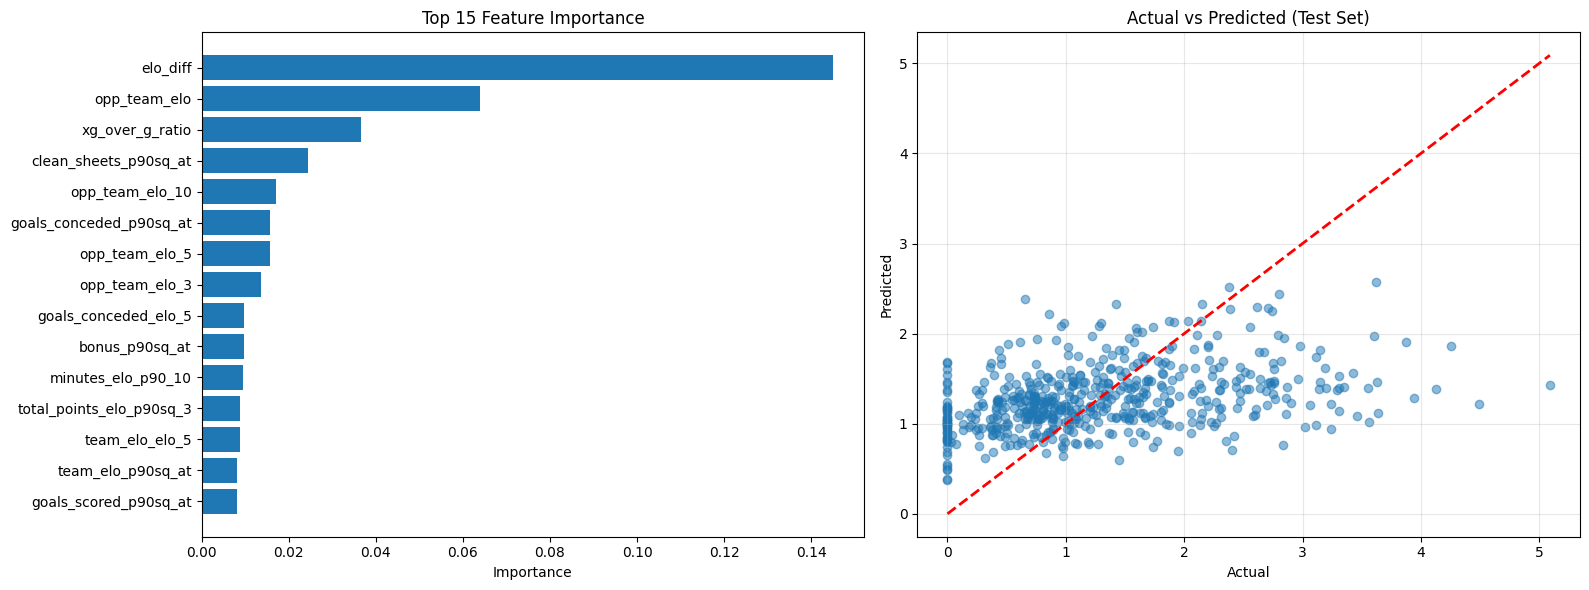

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 12211/18829

Training Set Performance:
R² Score: 0.5430
RMSE: 0.6358
MAE: 0.5029

Test Set Performance:
R² Score: 0.3137
RMSE: 0.7744
MAE: 0.6044

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.210262
         opp_team_elo    0.116915
             team_elo    0.037413
       opp_team_elo_5    0.035788
      opp_team_elo_10    0.034043
           team_elo_5    0.029373
       opp_team_elo_3    0.027315
          team_elo_10    0.024882
           team_elo_3    0.023128
   opp_team_elo_elo_3    0.018107
       team_elo_elo_3    0.016958
   opp_team_elo_elo_5    0.015472
       team_elo_elo_5    0.015033
    minutes_elo_p90_3    0.013636
  opp_team_elo_elo_10    0.012935
  minutes_elo_p90sq_3    0.012930
clean_sheets_p90sq_at    0.011740
      team_elo_elo_10    0.009805
 minutes_elo_p90sq_10    0.009777
  minutes_elo_p90sq_5    0.008783


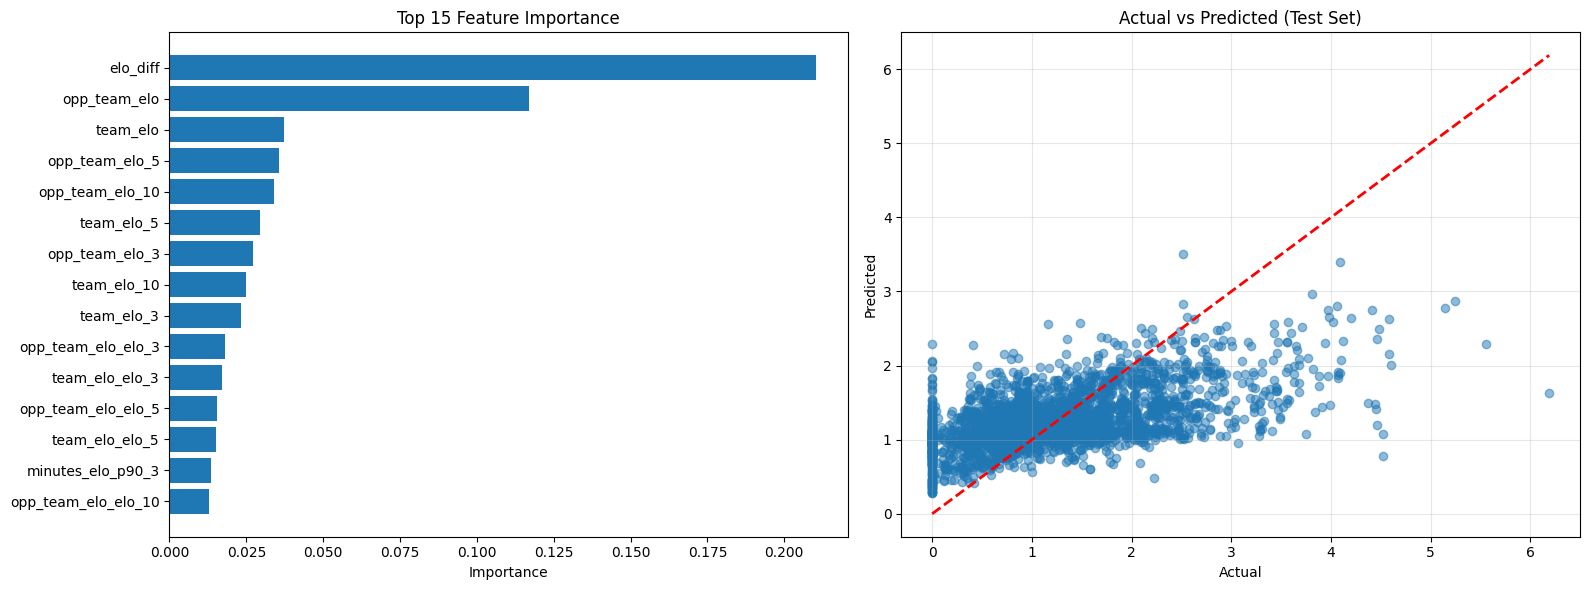

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10292/16608

Training Set Performance:
R² Score: 0.5808
RMSE: 0.6097
MAE: 0.4860

Test Set Performance:
R² Score: 0.3298
RMSE: 0.7588
MAE: 0.5852

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.204995
           opp_team_elo    0.083858
         opp_team_elo_5    0.036219
        opp_team_elo_10    0.028542
            team_elo_10    0.027236
    opp_team_elo_elo_10    0.023157
             team_elo_5    0.022380
               team_elo    0.021760
         opp_team_elo_3    0.020050
  clean_sheets_p90sq_at    0.017920
goals_conceded_p90sq_at    0.017795
             team_elo_3    0.017739
         team_elo_elo_3    0.017696
     opp_team_elo_elo_3    0.017045
     opp_team_elo_elo_5    0.014428
    minutes_elo_p90sq_3    0.012289
      minutes_elo_p90_3    0.011329
        team_elo_elo_10    0.011153
         team_elo_elo_5    0.010081
  opp_team_elo_p90sq_at    0.008

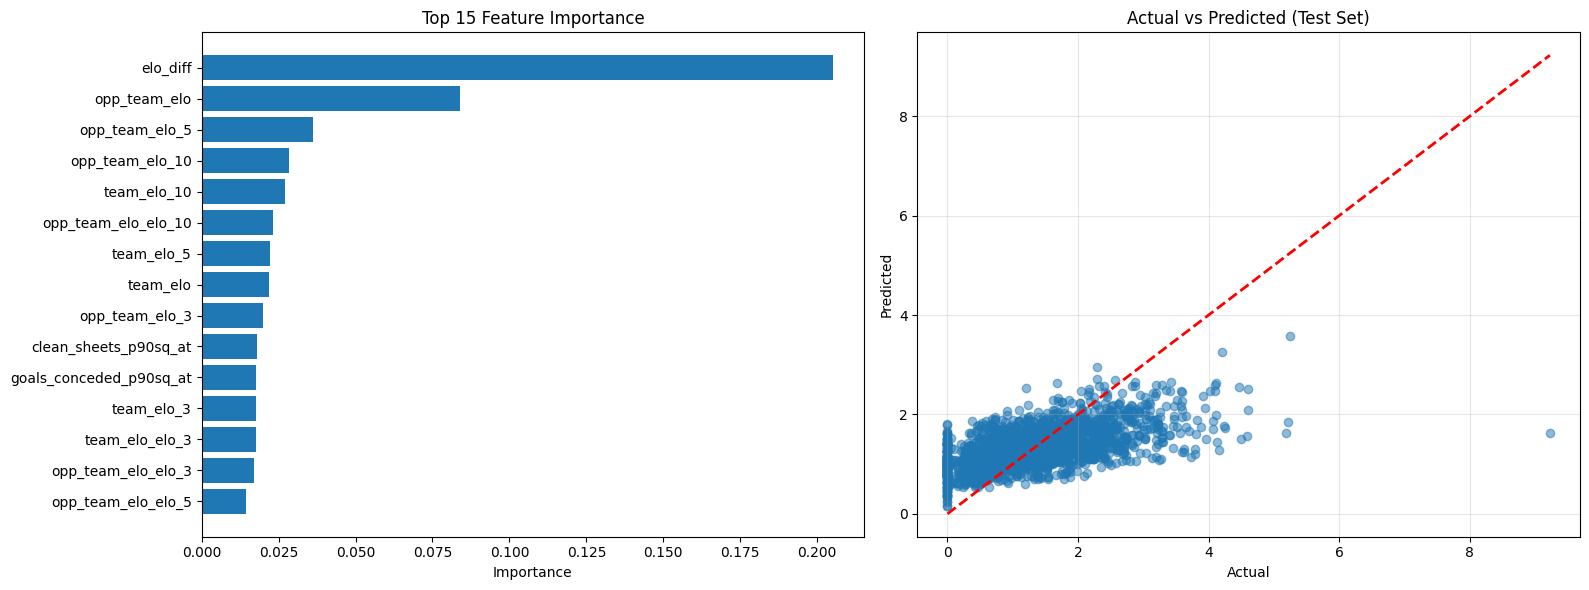

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2524/4059

Training Set Performance:
R² Score: 0.7107
RMSE: 0.5008
MAE: 0.4042

Test Set Performance:
R² Score: 0.1167
RMSE: 0.8351
MAE: 0.6542

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.170469
           opp_team_elo    0.043150
         saves_p90sq_at    0.031885
  opp_team_elo_p90sq_at    0.022364
  opp_team_elo_p90sq_10    0.022260
goals_conceded_p90sq_at    0.021074
      team_elo_p90sq_at    0.020475
        opp_team_elo_10    0.017288
     saves_elo_p90sq_10    0.015644
           bps_p90sq_at    0.013664
  total_points_p90sq_at    0.013407
         saves_p90sq_10    0.013313
      saves_elo_p90sq_3    0.011847
         opp_team_elo_3    0.011067
   opp_team_elo_p90sq_5    0.010864
          saves_p90sq_5    0.010811
   opp_team_elo_p90sq_3    0.010745
         opp_team_elo_5    0.010704
  clean_sheets_p90sq_at    0.010583
      saves_elo_p90sq_5    0.010451

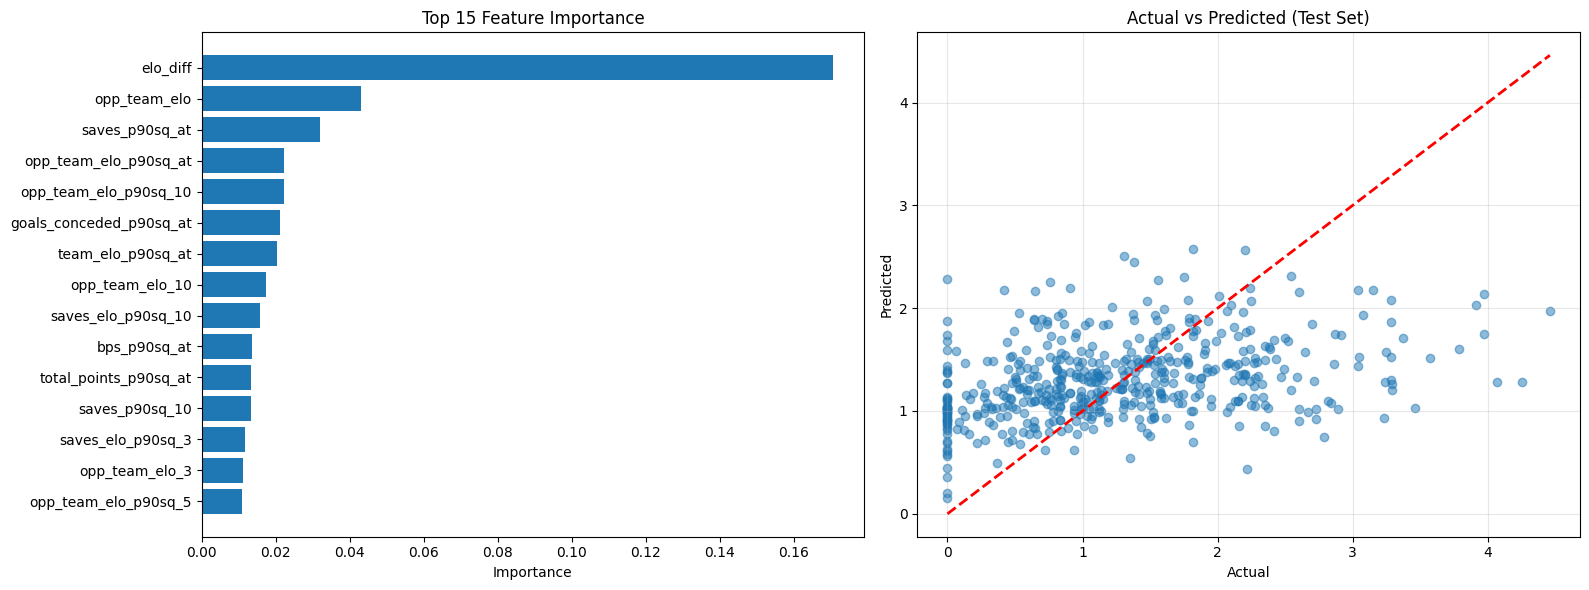

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4039/4538

Training Set Performance:
R² Score: 0.4910
RMSE: 13.3051
MAE: 10.7057

Test Set Performance:
R² Score: -0.0106
RMSE: 18.1233
MAE: 14.5155

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.080092
             opp_team_elo    0.029774
          opp_team_elo_10    0.019346
           opp_team_elo_5    0.017941
  goals_conceded_p90sq_at    0.016565
       opp_team_elo_elo_5    0.015587
        minutes_elo_p90_5    0.014747
     minutes_elo_p90sq_10    0.013843
      minutes_elo_p90sq_5    0.012688
           bonus_p90sq_at    0.012588
        minutes_elo_p90_3    0.011707
clean_sheets_elo_p90sq_10    0.011124
    total_points_p90sq_at    0.010786
           opp_team_elo_3    0.010616
             bps_p90sq_at    0.010263
                bps_elo_3    0.010074
    clean_sheets_p90sq_at    0.009784
    team_elo_elo_p90sq_10    0.009346
              bps_p90sq_5    0.009310
         

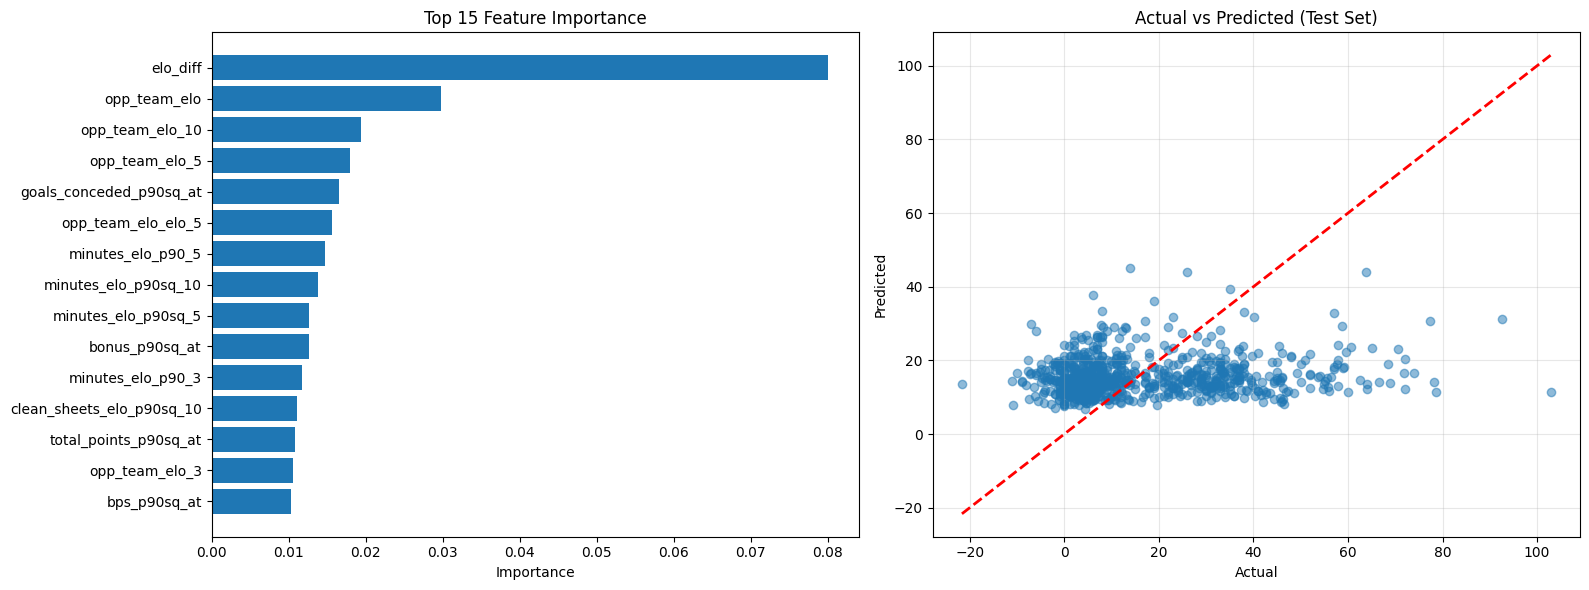

target=bps_per90, MID_bps_predictor
Cleaned df size: 18225/18829

Training Set Performance:
R² Score: 0.3274
RMSE: 9.4372
MAE: 7.1770

Test Set Performance:
R² Score: 0.0566
RMSE: 10.9884
MAE: 8.0175

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.127633
             bps_elo_10    0.030725
                 bps_10    0.027618
           opp_team_elo    0.022273
         bonus_p90sq_at    0.020606
        opp_team_elo_10    0.019412
         opp_team_elo_3    0.016157
                  bps_5    0.014574
         opp_team_elo_5    0.013259
           bps_p90sq_at    0.012322
  goals_scored_p90sq_at    0.011210
      team_elo_p90sq_at    0.010601
goals_conceded_p90sq_at    0.010200
    total_points_elo_10    0.009988
  total_points_p90sq_at    0.009462
  clean_sheets_p90sq_at    0.009439
              bps_p90_3    0.009247
              bps_elo_5    0.008997
   opp_team_elo_p90sq_3    0.008819
           bps_p90sq_10    0.008396


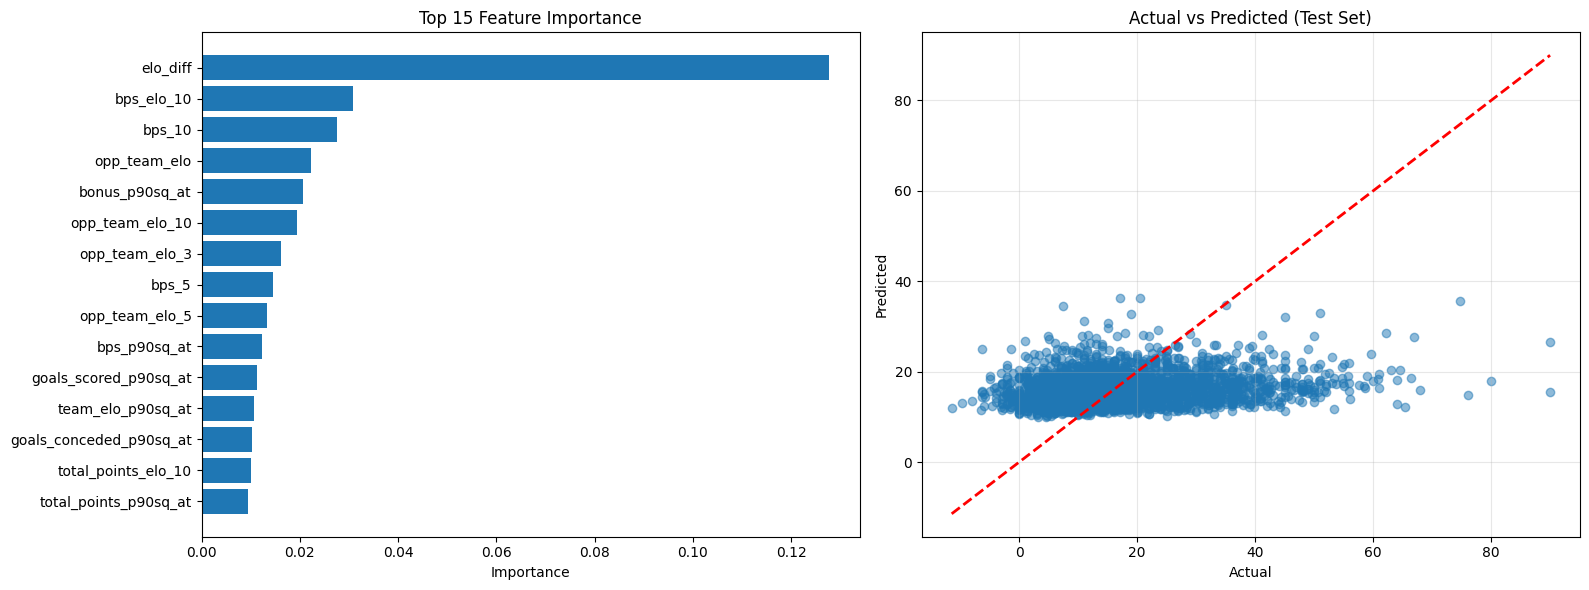

target=bps_per90, DEF_bps_predictor
Cleaned df size: 15619/16608

Training Set Performance:
R² Score: 0.4076
RMSE: 7.5776
MAE: 6.0570

Test Set Performance:
R² Score: 0.1536
RMSE: 9.1103
MAE: 7.1702

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.227654
           opp_team_elo    0.033100
        opp_team_elo_10    0.026020
         opp_team_elo_5    0.024412
         bonus_p90sq_at    0.019585
         opp_team_elo_3    0.019572
            bps_p90sq_5    0.015922
  clean_sheets_p90sq_at    0.011732
             bps_p90_10    0.011206
            team_elo_10    0.011182
goals_conceded_p90sq_at    0.011145
                 bps_10    0.010064
               team_elo    0.009689
        bps_elo_p90sq_3    0.009266
           bps_p90sq_at    0.009258
    minutes_elo_p90sq_3    0.008976
           bps_p90sq_10    0.008819
       bps_elo_p90sq_10    0.008785
              bps_p90_5    0.008724
  goals_scored_p90sq_at    0.008482


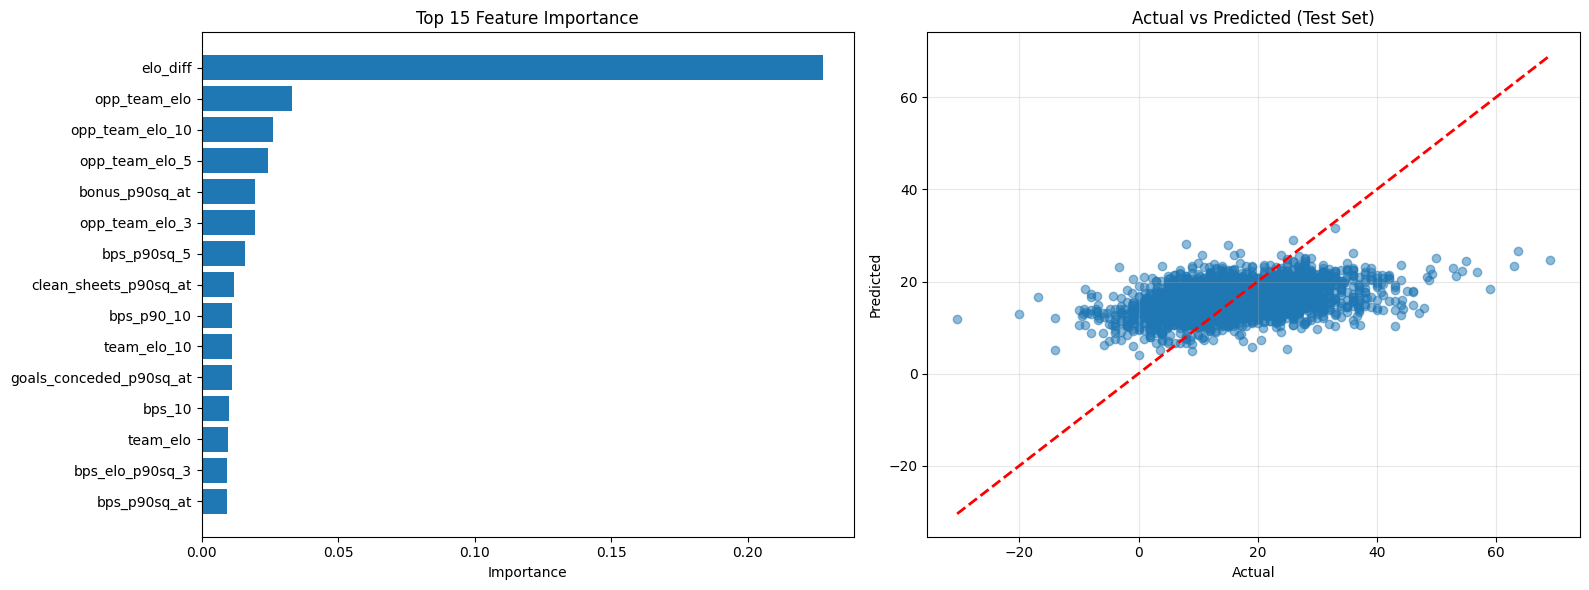

target=bps_per90, GK_bps_predictor
Cleaned df size: 3822/4059

Training Set Performance:
R² Score: 0.5472
RMSE: 5.9325
MAE: 4.8146

Test Set Performance:
R² Score: 0.0277
RMSE: 8.8629
MAE: 7.0883

Top 20 Feature Importances:
                    feature  importance
               bps_p90sq_10    0.031892
            opp_team_elo_10    0.027237
               opp_team_elo    0.026953
                 bps_p90_10    0.026434
               bps_p90sq_at    0.021142
                   elo_diff    0.020988
             saves_p90sq_10    0.019045
                     bps_10    0.017472
          saves_elo_p90sq_3    0.017031
             opp_team_elo_5    0.016591
      opp_team_elo_p90sq_at    0.016417
    goals_conceded_p90sq_at    0.016370
           bps_elo_p90sq_10    0.015163
                bps_p90sq_5    0.014670
             opp_team_elo_3    0.014544
          team_elo_p90sq_at    0.014507
      opp_team_elo_p90sq_10    0.014485
goals_conceded_elo_p90sq_10    0.013951
             bo

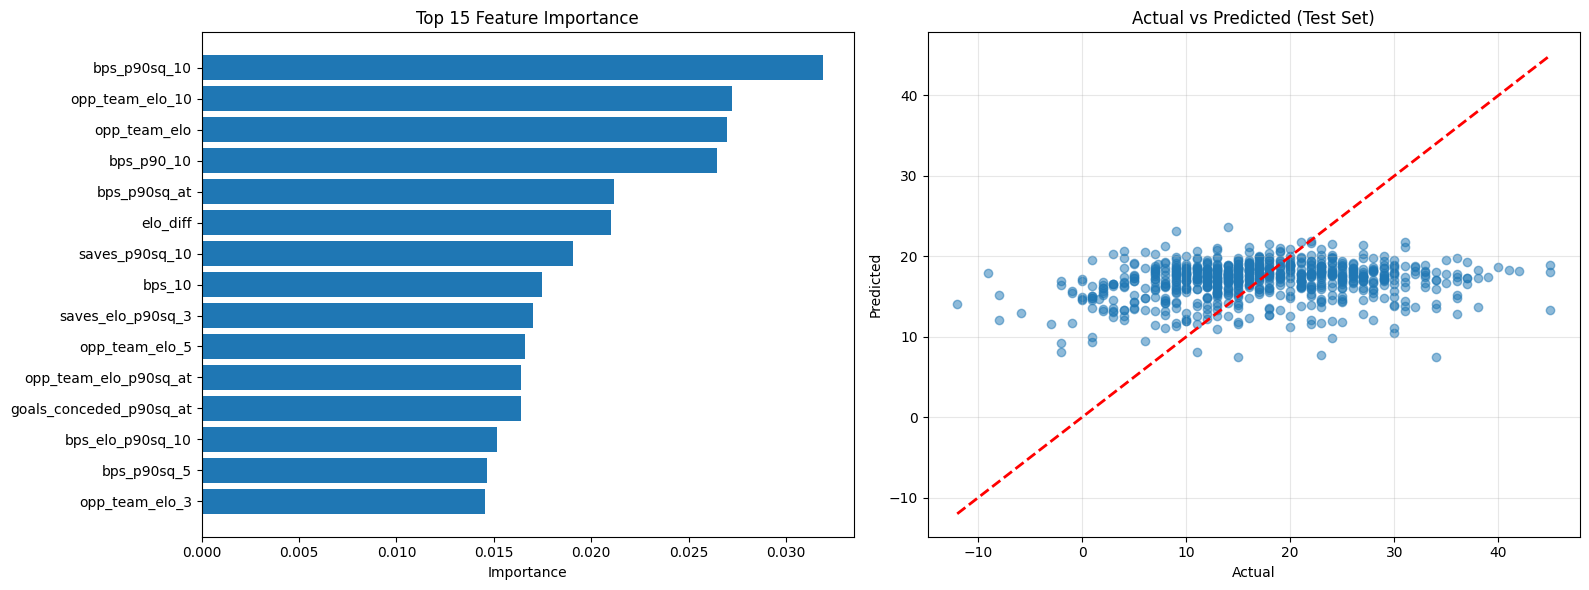

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3822/4079

Training Set Performance:
R² Score: 0.5870
RMSE: 1.2556
MAE: 1.0138

Test Set Performance:
R² Score: 0.0564
RMSE: 1.9361
MAE: 1.5073

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.143298
         saves_p90sq_at    0.019354
           opp_team_elo    0.018860
  opp_team_elo_p90sq_at    0.018125
        opp_team_elo_10    0.017003
         opp_team_elo_5    0.016096
      team_elo_p90sq_at    0.015985
goals_conceded_p90sq_at    0.015029
         saves_p90sq_10    0.014088
         opp_team_elo_3    0.013964
     saves_elo_p90sq_10    0.013750
           bps_p90sq_at    0.013734
  opp_team_elo_p90sq_10    0.013205
   opp_team_elo_p90sq_5    0.011147
        bps_elo_p90sq_5    0.010794
           bps_p90sq_10    0.010777
  total_points_p90sq_at    0.010596
            bps_p90sq_5    0.010532
         bonus_p90sq_at    0.010208
      saves_elo_p90sq_5    0.010171


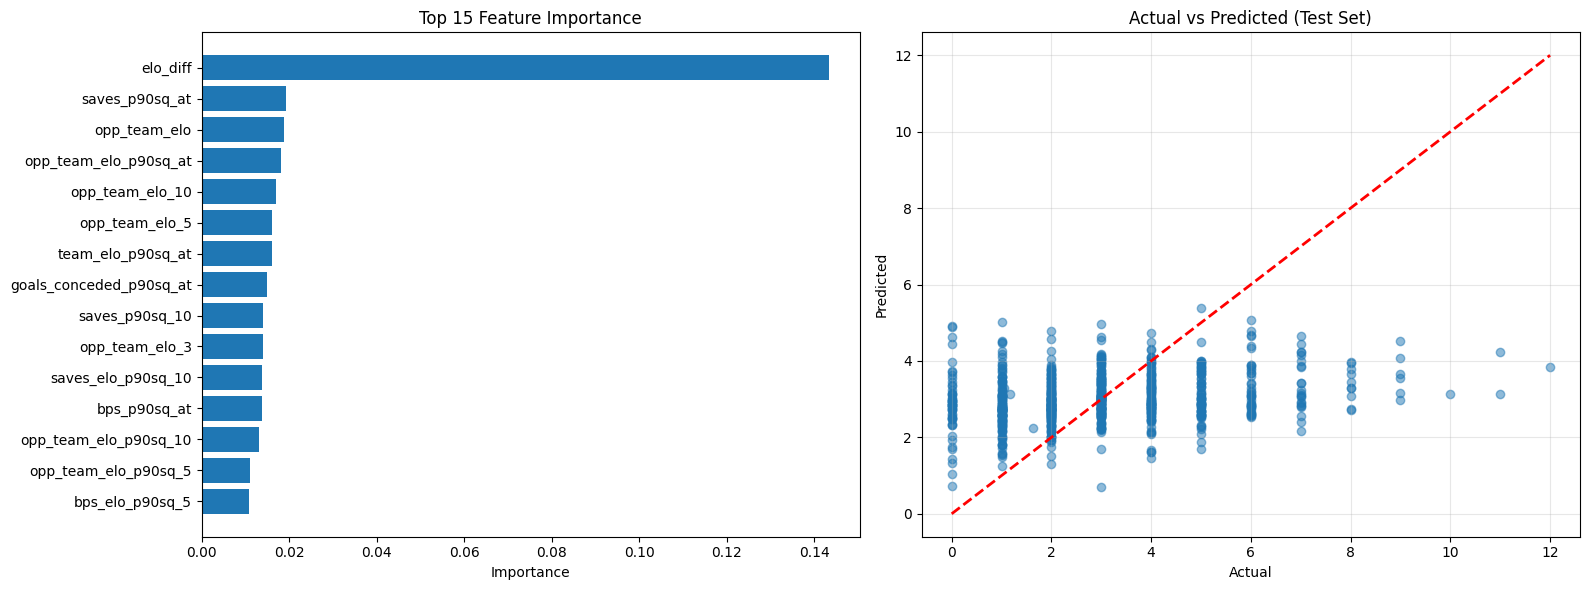

In [16]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 519/5017

Training Set Performance:
R² Score: 0.8242
RMSE: 1.1314
MAE: 0.9015

Test Set Performance:
R² Score: -0.1317
RMSE: 3.2462
MAE: 2.4463

Top 20 Feature Importances:
                feature  importance
  clean_sheets_p90sq_at    0.061229
      team_elo_p90sq_10    0.032187
  goals_scored_p90sq_at    0.031892
         opp_team_elo_5    0.025379
        opp_team_elo_10    0.023189
goals_conceded_p90sq_at    0.020861
           bps_p90sq_at    0.020592
               team_elo    0.018578
     minutes_elo_p90_10    0.017163
            bps_p90sq_5    0.015092
           opp_team_elo    0.014847
  goals_conceded_p90_10    0.014133
   goals_conceded_p90_5    0.013863
             minutes_10    0.013634
         bonus_p90sq_at    0.013605
               elo_diff    0.012447
       team_elo_p90sq_5    0.012356
 goals_conceded_p90sq_3    0.011514
         opp_team_elo_3    0.010972
  goals_conceded_elo_10    0.010

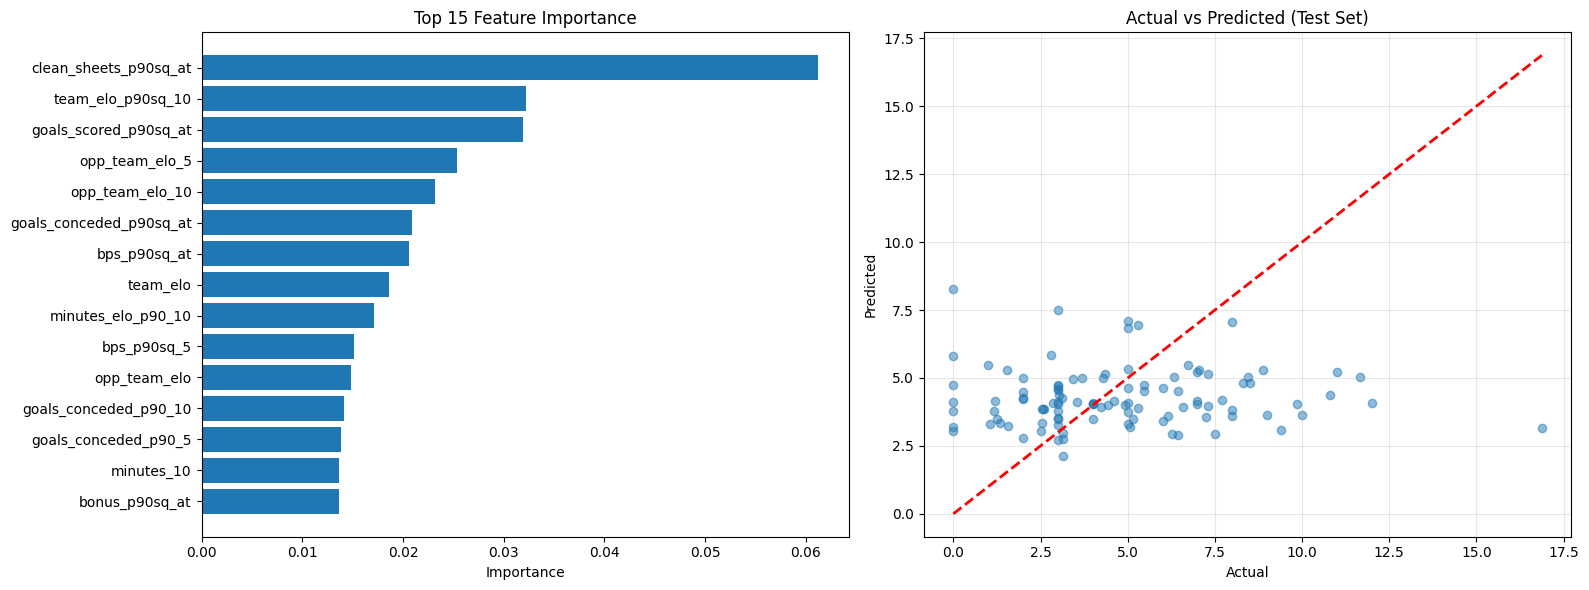

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 2452/20706

Training Set Performance:
R² Score: 0.6919
RMSE: 2.3321
MAE: 1.8878

Test Set Performance:
R² Score: 0.1765
RMSE: 3.9495
MAE: 3.0339

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.097332
      total_points_p90sq_at    0.029799
    goals_conceded_p90sq_at    0.026046
               bps_p90sq_at    0.021248
             bonus_p90sq_at    0.020876
           team_elo_p90sq_5    0.017343
      goals_conceded_elo_10    0.016244
          team_elo_p90sq_at    0.015424
      opp_team_elo_p90sq_at    0.014304
      clean_sheets_p90sq_at    0.013241
                   elo_diff    0.012258
                 bps_p90_10    0.011785
             opp_team_elo_3    0.011726
               opp_team_elo    0.011343
goals_conceded_elo_p90sq_10    0.011329
         minutes_elo_p90_10    0.011086
       opp_team_elo_p90sq_3    0.010921
                   team_elo    

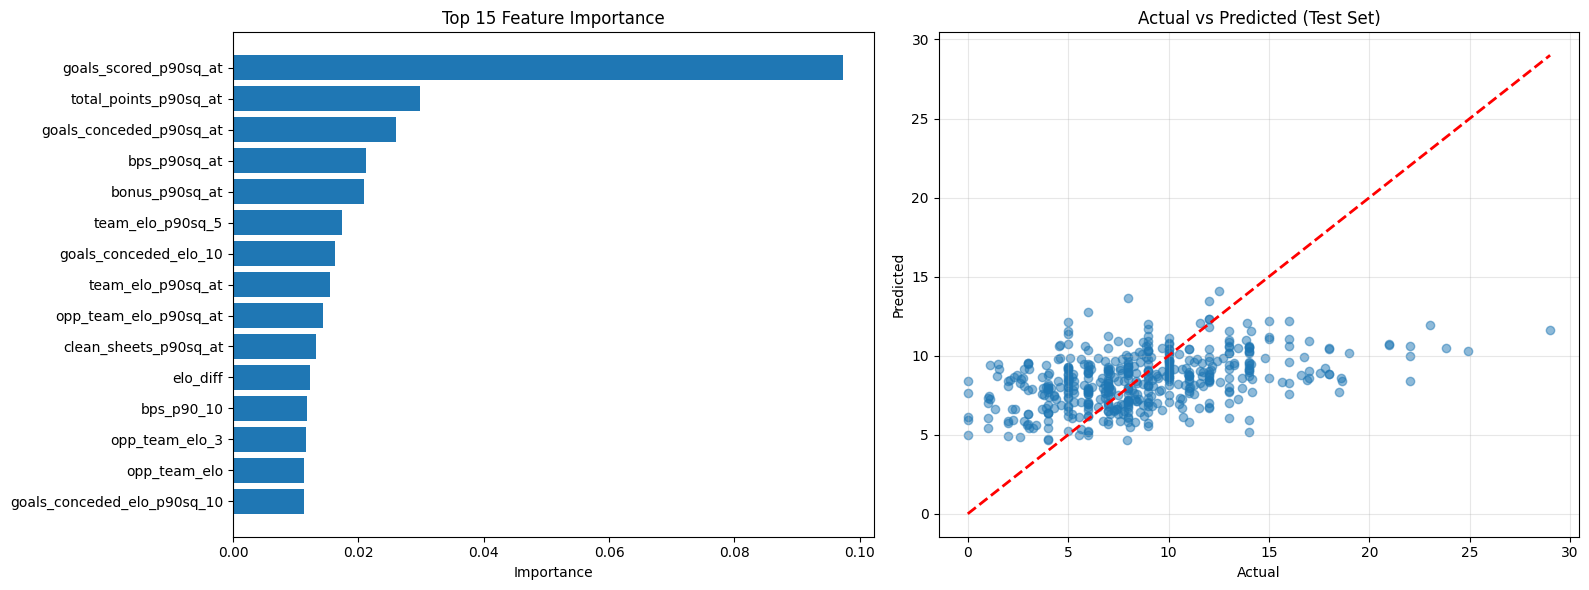

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 2059/17552

Training Set Performance:
R² Score: 0.6788
RMSE: 2.1896
MAE: 1.7834

Test Set Performance:
R² Score: 0.0467
RMSE: 3.7956
MAE: 2.9350

Top 20 Feature Importances:
                feature  importance
  opp_team_elo_p90sq_at    0.038688
           opp_team_elo    0.021804
       team_elo_p90sq_5    0.021131
               elo_diff    0.020170
goals_conceded_p90sq_at    0.020026
  goals_scored_p90sq_at    0.019384
   opp_team_elo_p90sq_5    0.018077
      team_elo_p90sq_at    0.018008
  total_points_p90sq_at    0.017485
opp_team_elo_elo_p90_10    0.017054
         opp_team_elo_3    0.015805
     minutes_elo_p90_10    0.014522
        opp_team_elo_10    0.014381
  opp_team_elo_p90sq_10    0.013982
  goals_conceded_elo_10    0.013855
           bps_p90sq_at    0.013718
  clean_sheets_p90sq_at    0.013336
         bonus_p90sq_at    0.012615
         opp_team_elo_5    0.012509
            team_elo_10    0.01

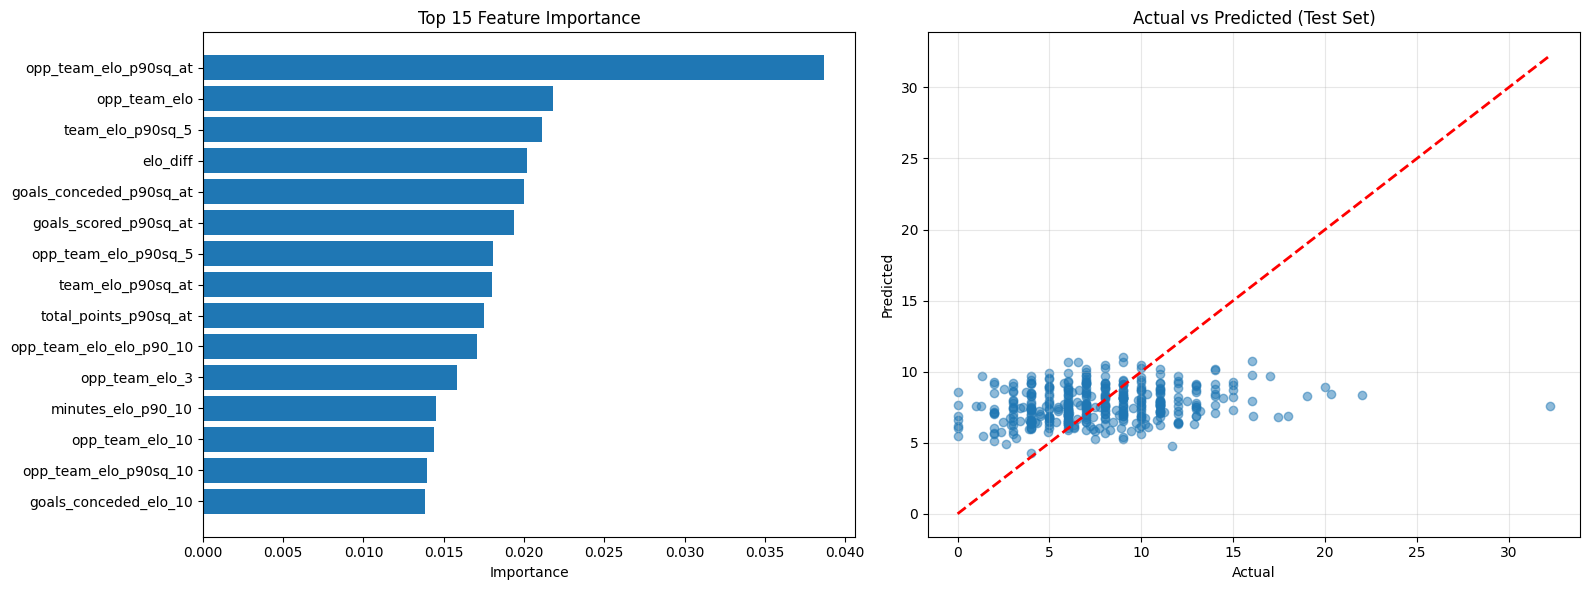

In [17]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

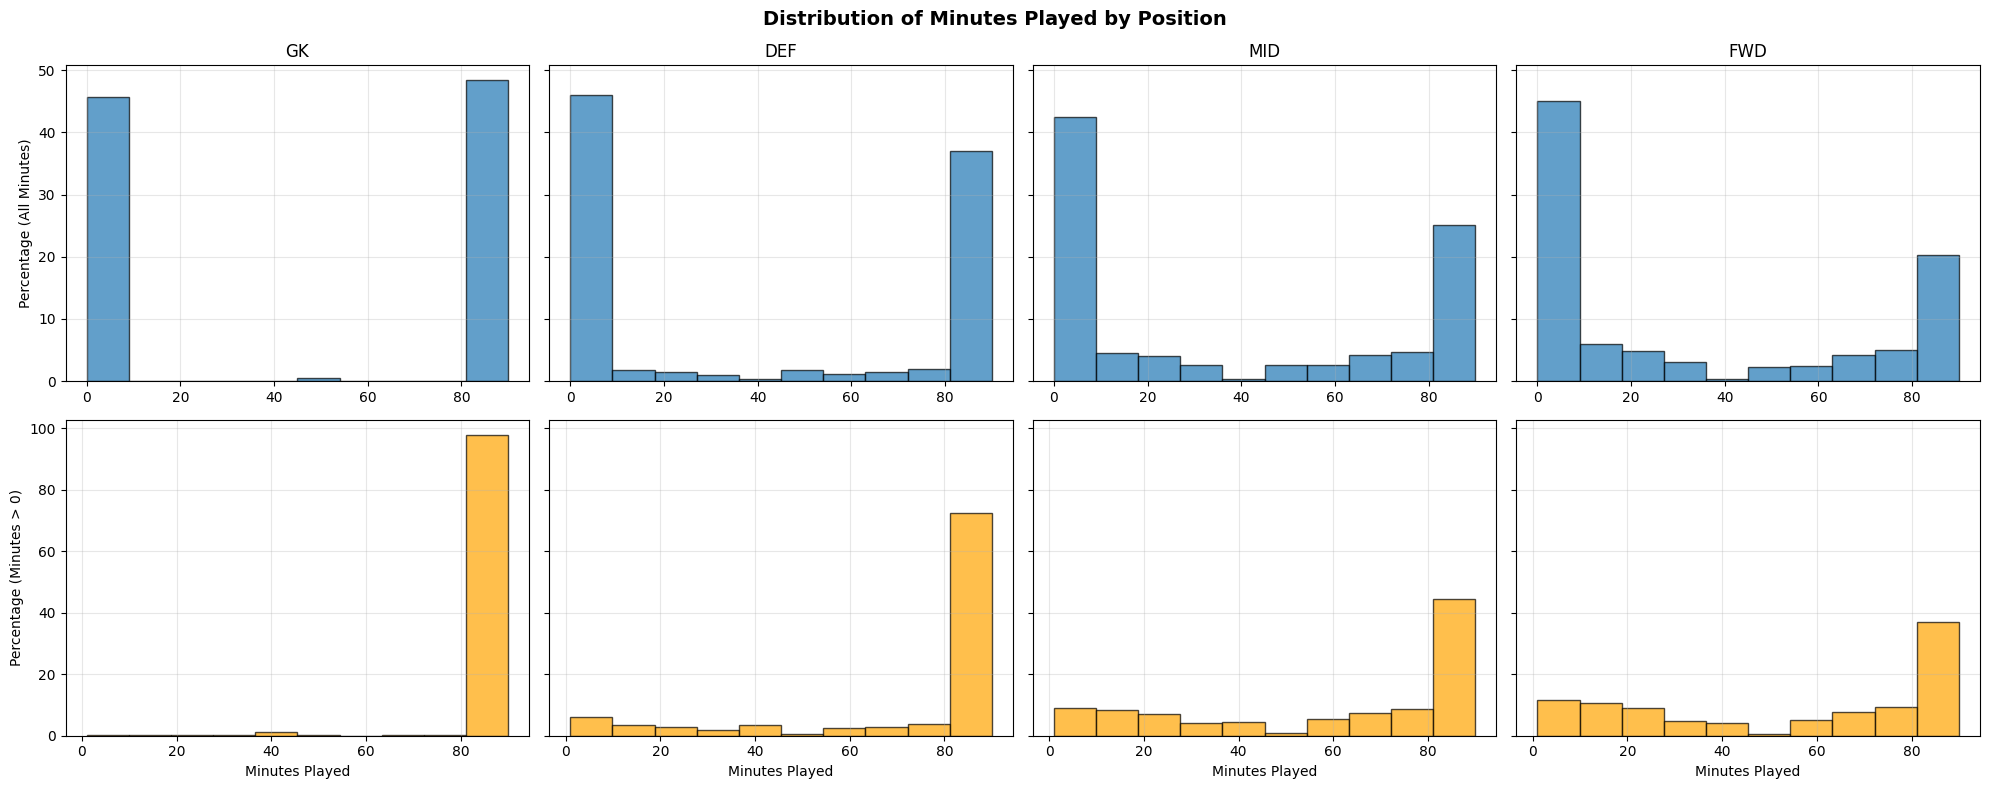

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.353


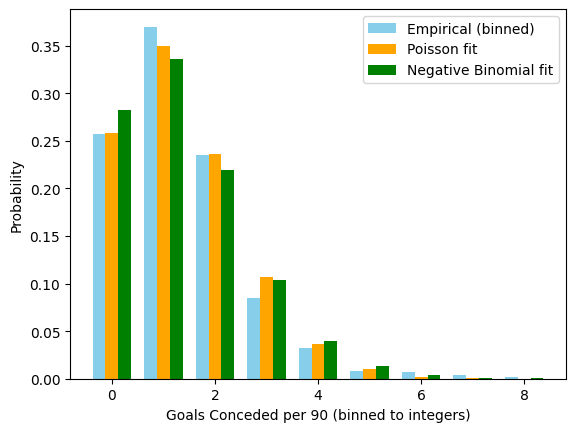

Mean: 1.344, Variance: 1.512
Overdispersion ratio (Var/Mean): 1.126
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.258


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.230


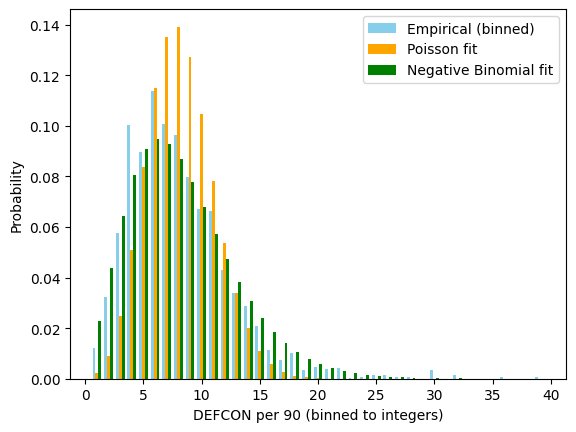

Mean: 8.221, Variance: 21.182
Overdispersion ratio (Var/Mean): 2.577
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [20]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.205


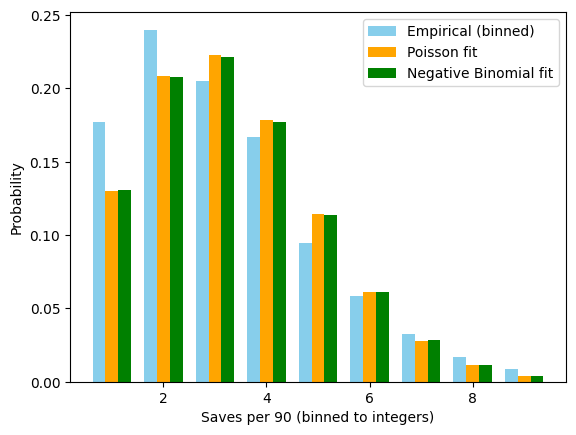

Mean: 3.205, Variance: 3.237
Overdispersion ratio (Var/Mean): 1.010
✅ Poisson assumption looks reasonable.


In [21]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [22]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=stats_current_gameweek+1)]

In [23]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [24]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    6540.000000
mean       60.357661
std        20.776075
min        12.751547
25%        40.510433
50%        61.666215
75%        80.690409
max        89.984330
Name: mins_pred, dtype: float64

In [25]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    6130.000000
mean        0.161016
std         0.139701
min         0.025163
25%         0.055409
50%         0.115859
75%         0.222726
max         0.861912
Name: xgp90_pred, dtype: float64

In [26]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    6130.000000
mean        0.099951
std         0.066945
min         0.026106
25%         0.050601
50%         0.077844
75%         0.129749
max         0.406444
Name: xap90_pred, dtype: float64

In [27]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    6540.000000
mean        1.433930
std         0.357181
min         0.460778
25%         1.169662
50%         1.433387
75%         1.654573
max         3.129444
Name: xgcp90_pred, dtype: float64

In [28]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    6540.000000
mean       15.884312
std         3.411883
min         4.828505
25%        13.594796
50%        15.572299
75%        17.806501
max        41.981124
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.423e+04
Date:                Mon, 09 Feb 2026   Prob (F-statistic):                        0.00
Time:                        12:28:53   Log-Likelihood:                         -39805.
No. Observations:               42235   AIC:                                  7.961e+04
Df Residuals:                   42234   BIC:                                  7.962e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

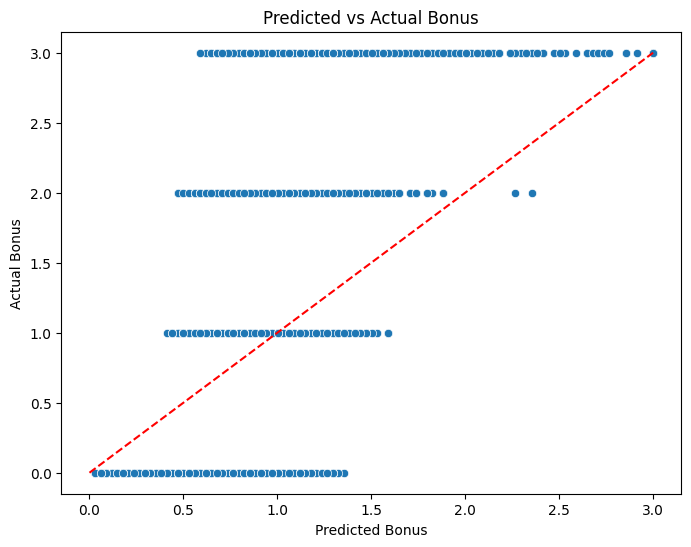

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459030  0.229977  1.106759  1.947397
FWD           0.332771  0.197112  1.047682  1.708584
GK            0.488995  0.244754  1.115468  2.011099
GKP                NaN       NaN       NaN       NaN
MID           0.396527  0.245108  1.049398  1.824117


C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [29]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [30]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [31]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    410.000000
mean       3.179436
std        0.665982
min        1.143213
25%        2.707354
50%        3.028939
75%        3.614114
max        5.009829
Name: xsavesp90_pred, dtype: float64

In [32]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    6130.000000
mean        7.786323
std         1.833913
min         2.561843
25%         6.763070
50%         7.996690
75%         9.022560
max        12.839470
Name: xdefconp90_pred, dtype: float64

In [33]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
130052,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,26.0,Burnley,876.125464,71.551799,0.076720,0.117127,0.978755
130053,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,27.0,Wolves,905.338012,71.551799,0.063248,0.107199,0.984823
130054,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,28.0,Man Utd,1099.663241,72.003829,0.051422,0.066420,1.473527
130055,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,29.0,Spurs,989.147818,71.657162,0.053791,0.071674,1.090203
130056,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,30.0,Leeds,983.473127,71.657162,0.061549,0.074852,1.090203


In [34]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
141590,Marc Guiu Paz,252.0,42.0,Chelsea,FWD,20252026.0,26.0,Leeds,983.473127,38.639190,0.815958,0.360363,1.748212
135587,Fábio Freitas Gouveia Carvalho,123.0,47.0,Brentford,MID,20252026.0,26.0,Arsenal,1249.677470,43.025670,0.706242,0.164694,1.854604
132364,Callum Marshall,626.0,43.0,West Ham,FWD,20252026.0,26.0,Man Utd,1099.663241,39.169255,0.703986,0.341006,1.848606
143720,Niclas Füllkrug,625.0,56.0,West Ham,FWD,20252026.0,26.0,Man Utd,1099.663241,43.055662,0.695954,0.335950,1.837221
146485,Saša Kalajdžić,656.0,49.0,Wolves,FWD,20252026.0,26.0,Arsenal,1249.677470,42.757573,0.690480,0.348728,2.342727
130361,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,26.0,Sunderland,1044.039767,33.278418,0.677893,0.348364,1.437481
144162,Odsonne Édouard,285.0,50.0,Crystal Palace,FWD,20252026.0,26.0,Burnley,876.125464,23.265860,0.661294,0.389151,2.002112
131611,Benjamin Sesko,681.0,72.0,Man Utd,FWD,20252026.0,26.0,West Ham,973.988320,34.060741,0.627002,0.067316,1.002799
141236,Lukas Nmecha,365.0,50.0,Leeds,FWD,20252026.0,26.0,Chelsea,1143.021180,23.957342,0.585247,0.231461,1.812716
131077,Arnaud Kalimuendo,696.0,60.0,Nott'm Forest,FWD,20252026.0,26.0,Wolves,905.338012,22.922757,0.584709,0.247613,1.683402


In [35]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [36]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [37]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_21640\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [38]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [39]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6540 entries, 0 to 6539
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          6540 non-null   object 
 1   team_name               6540 non-null   object 
 2   team_elo                6540 non-null   float64
 3   element                 6540 non-null   float64
 4   position                6540 non-null   object 
 5   opp_team_name           6540 non-null   object 
 6   opp_team_elo            6540 non-null   float64
 7   season                  6540 non-null   float64
 8   value                   6540 non-null   float64
 9   event                   6540 non-null   float64
 10  mins_pred               6540 non-null   float64
 11  xgp90_pred              6130 non-null   float64
 12  xap90_pred              6130 non-null   float64
 13  xgcp90_pred             6540 non-null   float64
 14  xpoints_mins            6540 non-null   

In [40]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [41]:
current_gameweek = picks_current_gameweek
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
""")

In [42]:
print(f"Gameweek {picks_current_gameweek+1} Predictions")
prediction_data[
    prediction_data['event']==picks_current_gameweek+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 26 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
135506,Florian Wirtz,382.0,26.0,83.0,Liverpool,MID,Sunderland,1044.039767,84.911498,1.923519,1.231300,0.645803,0.258318,0.0,0.000000,0.515538,0.654217,5.228694
131000,Antoine Semenyo,82.0,26.0,78.0,Man City,MID,Fulham,1043.298478,86.524124,1.934160,1.268467,0.570986,0.310886,0.0,0.000000,0.515538,0.541024,5.141059
135803,Gabriel dos Santos Magalhães,5.0,26.0,71.0,Arsenal,DEF,Brentford,1081.183298,83.690450,1.914436,0.363847,0.420190,1.593267,0.0,-0.249918,0.541959,0.550257,5.134039
143587,Nathaniel Clyne,263.0,26.0,38.0,Crystal Palace,DEF,Burnley,876.125464,58.242859,1.456184,1.151261,0.124375,1.552099,0.0,-0.260984,0.541959,0.561331,5.126226
139703,Jurriën Timber,8.0,26.0,64.0,Arsenal,DEF,Brentford,1081.183298,86.924048,1.936577,0.426903,0.263271,1.610893,0.0,-0.245299,0.541959,0.523861,5.058166
132180,Bruno Borges Fernandes,449.0,26.0,97.0,Man Utd,MID,West Ham,973.988320,78.447942,1.863515,1.030546,0.579129,0.340400,0.0,0.000000,0.515538,0.667922,4.997050
144363,Oleksandr Zinchenko,12.0,26.0,49.0,Nott'm Forest,DEF,Wolves,905.338012,63.794551,1.593742,1.211871,0.139307,1.240661,0.0,-0.359375,0.541959,0.579192,4.947357
142773,Murillo Costa dos Santos,506.0,26.0,52.0,Nott'm Forest,DEF,Wolves,905.338012,86.729415,1.935411,0.209674,0.140405,1.730876,0.0,-0.215645,0.541959,0.602366,4.945047
133388,Daniel Muñoz Mejía,256.0,26.0,58.0,Crystal Palace,DEF,Burnley,876.125464,82.322144,1.903105,0.326289,0.180354,1.633902,0.0,-0.239375,0.541959,0.587773,4.934007
132072,Bruno Guimarães Rodriguez Moura,488.0,26.0,71.0,Newcastle,MID,Spurs,989.147818,73.427537,1.792942,1.056997,0.589694,0.332744,0.0,0.000000,0.515538,0.625761,4.913677


In [43]:
current_gameweek=picks_current_gameweek
print(f"Next 5 GWs: GW{current_gameweek+1} - GW{current_gameweek+5}")
next_5_gws_filter = (prediction_data['event']>=current_gameweek)&(prediction_data['event']<=current_gameweek+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW26 - GW30


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
150,Florian Wirtz,424.557491,9.617595,6.325655,3.314643,1.846438,0.0,0.000000,2.577688,3.382289,27.064308
158,Gabriel dos Santos Magalhães,417.844118,9.567301,1.814614,2.100063,9.079422,0.0,-1.012859,2.709796,2.774876,27.033214
262,Jurriën Timber,434.620238,9.682885,2.140567,1.322774,9.205846,0.0,-0.982636,2.709796,2.632361,26.711593
31,Antoine Semenyo,432.620618,9.670798,6.396071,2.858193,1.447432,0.0,0.000000,2.577688,2.857200,25.807381
258,Joško Gvardiol,307.319634,7.682601,4.584652,1.341327,7.683386,0.0,-1.363985,2.709796,3.098596,25.736374
328,Matheus Nunes,434.007906,9.679228,1.165816,1.653372,8.439809,0.0,-1.166341,2.709796,3.208652,25.690332
116,Dominik Szoboszlai,431.781547,9.665599,4.865855,2.940944,1.860901,0.0,0.000000,2.577688,2.990319,24.901306
134,Erling Haaland,392.356153,9.318896,9.891346,0.840412,0.000000,0.0,0.000000,1.302659,3.104581,24.457895
373,Nico O'Reilly,422.356142,9.601754,1.389367,0.710205,8.110245,0.0,-1.259965,2.709796,2.945885,24.207287
354,Mohamed Salah,396.323953,9.364146,5.454315,2.397644,1.852435,0.0,0.000000,2.577688,2.512695,24.158922


In [44]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
150,Florian Wirtz,1103.849476,25.005748,16.114340,8.053766,3.795997,0.0,0.000000,6.701988,8.499498,68.171337
158,Gabriel dos Santos Magalhães,1001.861454,22.953782,4.409207,5.063460,22.485421,0.0,-2.308739,6.503512,6.574126,65.680770
262,Jurriën Timber,1043.097152,23.238975,5.147721,3.321550,22.750820,0.0,-2.247224,6.503512,6.257388,64.972741
358,Morgan Rogers,1122.047742,25.126904,13.342085,6.572866,4.108118,0.0,0.000000,6.701988,6.823562,62.675523
63,Bruno Borges Fernandes,1019.823249,24.225691,13.217752,6.590569,3.608134,0.0,0.000000,6.701988,7.835999,62.180135
116,Dominik Szoboszlai,1122.632023,25.130558,12.099378,6.840497,3.786205,0.0,0.000000,6.701988,7.411265,61.969892
31,Antoine Semenyo,1038.181075,23.209244,15.222133,6.502432,3.328632,0.0,0.000000,6.186451,6.671643,61.120535
354,Mohamed Salah,1033.646218,24.381971,13.841906,5.819905,3.903953,0.0,0.000000,6.701988,6.304778,60.954501
174,Harry Wilson,1104.756282,25.012050,12.392866,6.319961,3.493949,0.0,0.000000,6.701988,6.851158,60.771972
64,Bruno Guimarães Rodriguez Moura,962.051807,23.427296,13.832638,5.943073,3.286001,0.0,0.000000,6.701988,7.487027,60.678024


In [45]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': stats_current_gameweek
})

In [46]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [47]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [48]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 6540 new predictions to predictions_allgws


In [49]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==stats_current_gameweek) & (
    view['event']==stats_current_gameweek+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points
50763,Erling Haaland,26.0,20252026.0,NaN


In [50]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
181207,Erling Haaland,13.0,20252026.0,2.0,90.0
181208,Erling Haaland,14.0,20252026.0,14.0,90.0
181209,Erling Haaland,15.0,20252026.0,2.0,68.0
181210,Erling Haaland,16.0,20252026.0,13.0,90.0
181211,Erling Haaland,17.0,20252026.0,16.0,90.0
181212,Erling Haaland,18.0,20252026.0,2.0,90.0
181213,Erling Haaland,19.0,20252026.0,2.0,90.0
181214,Erling Haaland,20.0,20252026.0,2.0,90.0
181215,Erling Haaland,21.0,20252026.0,6.0,90.0
181216,Erling Haaland,22.0,20252026.0,2.0,79.0


In [51]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
...,...,...,...,...,...
19374,Erling Haaland,2026-01-27 11:00:04.422834,38.0,3.494566,NaN
5672,Erling Haaland,2026-01-26 14:27:00.627006,38.0,3.537848,NaN
33637,Erling Haaland,2026-02-02 13:38:00.840050,38.0,3.814370,NaN
40654,Erling Haaland,2026-02-03 14:41:19.430154,38.0,3.970624,NaN


In [52]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=stats_current_gameweek)&(
                df_preds['event']<=stats_current_gameweek+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 25.0   3.409847
                                                          26.0   3.426947
                                                          27.0   3.437517
                                                          28.0   3.421395
                                                          29.0   3.392790
...                                                                   ...
2026-02-09 12:29:03.939012 25                  20252026.0 26.0   3.411336
                                                          27.0   3.436457
                                                          28.0   3.408620
                                                          29.0   3.415774
                                                          30.0   3.435049

[65 rows x 1 columns]

In [53]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [54]:
df_complete.columns.to_list()

['player_name_id',
 'team_name',
 'team_elo',
 'element',
 'position',
 'opp_team_name',
 'opp_team_elo',
 'season',
 'value',
 'event',
 'mins_pred',
 'xgp90_pred',
 'xap90_pred',
 'xgcp90_pred',
 'xpoints_mins',
 'xpoints_goals',
 'xpoints_assists',
 'xpoints_clean_sheets',
 'xpoints_shots_saved',
 'xpoints_goals_conceded',
 'xpoints_defcon',
 'xpoints_bonus',
 'xpoints',
 'in_any_team',
 'in_my_team',
 'prediction_timestamp',
 'prediction_gameweek',
 'total_points',
 'fixture']

In [55]:
filtered = (df_complete['player_name_id'] == 'Bukayo Saka')&(
    df_complete['season']==20252026) & (df_complete['event']==25)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points
8758,2026-01-05 18:33:33.065519,20,20252026.0,25.0,4.681309,NaN
5587,2026-01-26 14:27:00.627006,23,20252026.0,25.0,4.317207,NaN
19293,2026-01-27 11:00:04.422834,23,20252026.0,25.0,4.290200,NaN
26546,2026-02-01 11:57:12.353330,24,20252026.0,25.0,4.248147,NaN
33565,2026-02-02 13:38:00.840050,24,20252026.0,25.0,4.271634,NaN
40577,2026-02-03 14:41:19.430154,24,20252026.0,25.0,4.078639,NaN


In [56]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,27.500000
min,2026-01-07 16:29:20.849190,25.000000
25%,2026-01-07 16:29:20.849189888,26.000000
50%,2026-01-08 04:37:05.395073024,27.500000
75%,2026-01-08 16:44:49.940955904,29.000000
max,2026-01-08 16:44:49.940956,30.000000
std,NaN,1.744557


In [57]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{stats_current_gameweek}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [58]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 29.85 minute(s)


In [59]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)